# Firm Panel Manual Audit

This notebook checks only the rebuilt firm panel: `data/processed/panel_v2/firm_panel_v2.parquet` or the CSV fallback. It is meant for manual inspection in VS Code/Jupyter before using the dataset in the thesis, dashboard, or GitHub deliverable.

The notebook does not modify the panel. Optional exports are disabled by default.

In [24]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    HAS_SEABORN = True
except Exception:
    HAS_SEABORN = False

from IPython.display import display

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 140)
pd.set_option('display.max_rows', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

EXPORT_RESULTS = False
EXPORT_DIR_NAME = 'reports/manual_panel_audit'

def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    candidates = [start, *start.parents]
    for candidate in candidates:
        if (candidate / 'data/processed/panel_v2').exists():
            return candidate
    raise FileNotFoundError('Could not find project root containing data/processed/panel_v2')

PROJECT_ROOT = find_project_root()
PANEL_PARQUET = PROJECT_ROOT / 'data/processed/panel_v2/firm_panel_v2.parquet'
PANEL_CSV = PROJECT_ROOT / 'data/processed/panel_v2/firm_panel_v2.csv.gz'
EXPORT_DIR = PROJECT_ROOT / EXPORT_DIR_NAME

print('Project root:', PROJECT_ROOT)
print('Panel parquet exists:', PANEL_PARQUET.exists())
print('Panel CSV exists:', PANEL_CSV.exists())

Project root: /Users/whotfisart/codex/Thesis work/market_shifts_clean
Panel parquet exists: True
Panel CSV exists: True


## 1. Load Panel

In [25]:
if PANEL_PARQUET.exists():
    df = pd.read_parquet(PANEL_PARQUET)
    source_path = PANEL_PARQUET
elif PANEL_CSV.exists():
    df = pd.read_csv(PANEL_CSV, low_memory=False)
    source_path = PANEL_CSV
else:
    raise FileNotFoundError('No firm_panel_v2 parquet or CSV file found')

DATE_COLS = ['period_date', 'filed_date', 'prediction_date', 'event_date']
for col in DATE_COLS:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

TARGET_COLS = [col for col in [
    'distress_next_2q',
    'distress_next_4q',
    'distress_next_8q',
    'broad_distress_next_4q',
    'healthy_current',
    'success_profitability_next_4q',
    'success_resilience_next_4q',
    'success_quality_next_4q',
    'post_event_flag',
    'formal_distress_firm',
    'near_distress_firm',
] if col in df.columns]

for col in TARGET_COLS:
    df[col] = pd.to_numeric(df[col], errors='coerce')

if 'prediction_date' in df.columns:
    df['manual_temporal_split'] = np.select(
        [df['prediction_date'].dt.year <= 2018,
         df['prediction_date'].dt.year.between(2019, 2021),
         df['prediction_date'].dt.year.between(2022, 2024)],
        ['train', 'validation', 'test'],
        default='unused'
    )

print('Loaded:', source_path)
print('Shape:', df.shape)
display(df.head())

Loaded: /Users/whotfisart/codex/Thesis work/market_shifts_clean/data/processed/panel_v2/firm_panel_v2.parquet
Shape: (22713, 181)


,adsh,cik,name,sic,afs,form,period,fy,fp,filed,sec_zip,accounts_receivable,capex,cash_equivalents,cash_flow_financing,cash_flow_investing,cash_flow_operating,cost_of_revenue,current_assets,current_liabilities,depreciation_amortization,eps_basic,eps_diluted,gross_profit,inventory,long_term_debt,net_income,operating_income,ppe_net,pretax_income,r_and_d_expense,retained_earnings,sg_and_a,shares_outstanding,short_term_debt,total_assets,total_equity,total_liabilities,total_revenue,wavg_shares_basic,wavg_shares_diluted,ticker,firm_id,shortname,sec_name,exchange,Sector,Industry,cohort,include_status,notes,period_date,filed_date,prediction_date,prediction_date_source,calendar_year,calendar_quarter,prediction_year,prediction_quarter,sic_sector,leverage_assets,equity_assets,current_ratio,cash_assets,net_margin,operating_margin,gross_margin,roa,r_and_d_intensity,inventory_assets,...,CPIAUCSL_yoy_pct,PPIACO,PPIACO_yoy_pct,PAYEMS,PAYEMS_yoy_pct,RSAFS,RSAFS_yoy_pct,HOUST,HOUST_yoy_pct,BUSLOANS,BUSLOANS_yoy_pct,DRTSCILM,high_rate_regime,market_stress_regime,tight_financial_conditions,credit_spread_stress_regime,yield_curve_inversion_regime,inflation_pressure_regime,oil_shock_regime,strong_dollar_regime,demand_slowdown_regime,credit_tightening_regime,crisis_regime,global_event_count,global_event_severity_sum,global_event_banking_stress_count,global_event_banking_stress_severity,global_event_commodity_oil_count,global_event_commodity_oil_severity,global_event_financial_crisis_count,global_event_financial_crisis_severity,global_event_financial_market_count,global_event_financial_market_severity,global_event_geopolitical_war_count,global_event_geopolitical_war_severity,global_event_monetary_inflation_count,global_event_monetary_inflation_severity,global_event_natural_disaster_count,global_event_natural_disaster_severity,global_event_pandemic_count,global_event_pandemic_severity,global_event_political_policy_count,global_event_political_policy_severity,global_event_sovereign_debt_count,global_event_sovereign_debt_severity,global_event_supply_chain_count,global_event_supply_chain_severity,global_event_trade_policy_count,global_event_trade_policy_severity,global_event_names,event_year,event_date,event_type,event_label,verification_status,formal_distress_firm,near_distress_firm,days_from_period_to_event,days_to_event,post_event_flag,distress_next_2q,distress_next_4q,distress_next_8q,broad_distress_next_4q,healthy_current,resilient_profitability,success_profitability_next_4q,success_resilience_next_4q,success_quality_next_4q,manual_temporal_split
0,0001140361-09-022500,1090872,AGILENT TECHNOLOGIES INC,3825,1-LAF,10-Q/A,20090731,"2,009.0000",Q3,20091005,2009q4,"770,000,000.0000",NaN,"1,826,000,000.0000",NaN,NaN,NaN,"518,000,000.0000","2,897,000,000.0000","1,330,000,000.0000",NaN,-0.0600,-0.0600,NaN,"571,000,000.0000",NaN,"169,000,000.0000","-1,000,000.0000","824,000,000.0000",NaN,"153,000,000.0000","2,791,000,000.0000","387,000,000.0000",NaN,NaN,"7,007,000,000.0000","2,489,000,000.0000","4,084,000,000.0000","1,444,000,000.0000","362,000,000.0000","345,000,000.0000",A,CIK0001090872,None,"AGILENT TECHNOLOGIES, INC.",NYSE,Technology,None,additional_controls,include_if_num_tags_parse,Existing extra ticker list; use as matched non...,2009-07-31,2009-10-05,2009-10-05,filed_date,2009,3,2009,4,Technology,0.5828,0.3552,2.1782,0.2606,0.1170,-0.0007,NaN,0.0241,0.1060,0.0815,...,-0.2240,175.2000,-6.0086,130061,-4.5711,334595,-3.3345,534,-31.2741,"1,308.1789",-17.5647,14.0000,0,1,1,1,0,0,0,0,1,1,1,1,5.0000,0,0.0000,0,0.0000,1,5.0000,0,0.0000,0,0.0000,0,0.0000,0,0.0000,0,0.0000,0,0.0000,0,0.0000,0,0.0000,0,0.0000,Global financial crisis aftershock,NaN,NaT,None,None,None,0,0,NaN,NaN,0,0,0,0,0,1,1,1,1,1,train
1,0001047469-09-010861,1090872,AGILENT TECHNOLOGIES INC,3825,1-LAF,10-K,20091031,"2,009.0000",FY,20091221,2009q4,"770,000,000.0000","44,000,000.0000","1,405,000,000.0000","-638,000,000.0000","-433,000,000.0000","213,000,000.0000","795,000,000.0000","3,182,000,00

## 2. Fast Panel Snapshot

In [26]:
def safe_min(series):
    return series.min() if series.notna().any() else pd.NaT

def safe_max(series):
    return series.max() if series.notna().any() else pd.NaT

snapshot = {
    'rows': len(df),
    'columns': df.shape[1],
    'unique_cik': df['cik'].nunique() if 'cik' in df else np.nan,
    'unique_ticker': df['ticker'].nunique() if 'ticker' in df else np.nan,
    'unique_adsh': df['adsh'].nunique() if 'adsh' in df else np.nan,
    'period_date_min': safe_min(df['period_date']) if 'period_date' in df else pd.NaT,
    'period_date_max': safe_max(df['period_date']) if 'period_date' in df else pd.NaT,
    'prediction_date_min': safe_min(df['prediction_date']) if 'prediction_date' in df else pd.NaT,
    'prediction_date_max': safe_max(df['prediction_date']) if 'prediction_date' in df else pd.NaT,
    'memory_mb': df.memory_usage(deep=True).sum() / 1024**2,
}
display(pd.Series(snapshot, name='panel_snapshot').to_frame())

if 'manual_temporal_split' in df.columns:
    display(df['manual_temporal_split'].value_counts(dropna=False).rename_axis('split').to_frame('rows'))

,panel_snapshot
rows,22713
columns,181
unique_cik,390
unique_ticker,391
unique_adsh,22646
period_date_min,2009-03-31 00:00:00
period_date_max,2026-02-28 00:00:00
prediction_date_min,2009-04-15 00:00:00
prediction_date_max,2026-03-31 00:00:00
memory_mb,57.2213


,rows
split,
train,12084
test,4431
validation,4384
unused,1814


## 3. Column Catalog and Missingness Overview

In [27]:
def example_values(series, n=4):
    values = series.dropna().astype(str).unique()[:n]
    return ', '.join(values)

column_catalog = pd.DataFrame({
    'column': df.columns,
    'dtype': [str(df[col].dtype) for col in df.columns],
    'missing_rows': [int(df[col].isna().sum()) for col in df.columns],
    'missing_share': [float(df[col].isna().mean()) for col in df.columns],
    'unique_values': [df[col].nunique(dropna=True) for col in df.columns],
    'example_values': [example_values(df[col]) for col in df.columns],
}).sort_values(['missing_share', 'column'], ascending=[False, True])

display(column_catalog.head(60))

if EXPORT_RESULTS:
    EXPORT_DIR.mkdir(parents=True, exist_ok=True)
    column_catalog.to_csv(EXPORT_DIR / 'firm_panel_column_catalog.csv', index=False)

,column,dtype,missing_rows,missing_share,unique_values,example_values
168,days_from_period_to_event,float64,21111,0.9295,1301,"517.0, 425.0, 333.0, 243.0"
169,days_to_event,float64,21111,0.9295,1382,"496.0, 405.0, 286.0, 223.0"
162,event_date,datetime64[ns],21111,0.9295,38,"2011-11-29, 2020-12-31, 2015-08-03, 2020-07-23"
164,event_label,object,21111,0.9295,2,"formal_distress, near_distress"
163,event_type,object,21111,0.9295,4,"bankruptcy, near_distress, liquidation_distres..."
161,event_year,float64,21111,0.9295,13,"2011.0, 2020.0, 2015.0, 2023.0"
165,verification_status,object,21111,0.9295,1,initial_seed
25,long_term_debt,float64,20934,0.9217,1123,"2729000000.0, 2733000000.0, 2735000000.0, 2555..."
68,r_and_d_intensity,float64,17022,0.7494,5435,"0.10595567867036011, 0.10195813639432816, 0.12..."
30,r_and_d_expense,float64,16919,0.7449,3465,"153000000.0, 151000000.0, 149000000.0, 1700000..."


## 4. Duplicate and Key Checks

In [28]:
candidate_keys = [
    ['adsh'],
    ['cik', 'period_date', 'form', 'filed_date'],
    ['cik', 'prediction_date', 'form'],
    ['ticker', 'prediction_date', 'form'],
]

key_rows = []
duplicate_samples = {}
for key in candidate_keys:
    if not set(key).issubset(df.columns):
        continue
    duplicate_mask = df.duplicated(key, keep=False)
    key_name = ' + '.join(key)
    key_rows.append({
        'key': key_name,
        'duplicate_rows': int(duplicate_mask.sum()),
        'duplicate_groups': int(df.loc[duplicate_mask].groupby(key, dropna=False).ngroups) if duplicate_mask.any() else 0,
        'unique_groups': int(df.groupby(key, dropna=False).ngroups),
    })
    duplicate_samples[key_name] = df.loc[duplicate_mask].sort_values(key).head(20)

duplicate_report = pd.DataFrame(key_rows)
display(duplicate_report)

for key_name, sample in duplicate_samples.items():
    if len(sample):
        print('\nDuplicate sample for:', key_name)
        display(sample.head(10))

,key,duplicate_rows,duplicate_groups,unique_groups
0,adsh,134,67,22646
1,cik + period_date + form + filed_date,134,67,22646
2,cik + prediction_date + form,157,75,22631
3,ticker + prediction_date + form,23,8,22698



Duplicate sample for: adsh


,adsh,cik,name,sic,afs,form,period,fy,fp,filed,sec_zip,accounts_receivable,capex,cash_equivalents,cash_flow_financing,cash_flow_investing,cash_flow_operating,cost_of_revenue,current_assets,current_liabilities,depreciation_amortization,eps_basic,eps_diluted,gross_profit,inventory,long_term_debt,net_income,operating_income,ppe_net,pretax_income,r_and_d_expense,retained_earnings,sg_and_a,shares_outstanding,short_term_debt,total_assets,total_equity,total_liabilities,total_revenue,wavg_shares_basic,wavg_shares_diluted,ticker,firm_id,shortname,sec_name,exchange,Sector,Industry,cohort,include_status,notes,period_date,filed_date,prediction_date,prediction_date_source,calendar_year,calendar_quarter,prediction_year,prediction_quarter,sic_sector,leverage_assets,equity_assets,current_ratio,cash_assets,net_margin,operating_margin,gross_margin,roa,r_and_d_intensity,inventory_assets,...,CPIAUCSL_yoy_pct,PPIACO,PPIACO_yoy_pct,PAYEMS,PAYEMS_yoy_pct,RSAFS,RSAFS_yoy_pct,HOUST,HOUST_yoy_pct,BUSLOANS,BUSLOANS_yoy_pct,DRTSCILM,high_rate_regime,market_stress_regime,tight_financial_conditions,credit_spread_stress_regime,yield_curve_inversion_regime,inflation_pressure_regime,oil_shock_regime,strong_dollar_regime,demand_slowdown_regime,credit_tightening_regime,crisis_regime,global_event_count,global_event_severity_sum,global_event_banking_stress_count,global_event_banking_stress_severity,global_event_commodity_oil_count,global_event_commodity_oil_severity,global_event_financial_crisis_count,global_event_financial_crisis_severity,global_event_financial_market_count,global_event_financial_market_severity,global_event_geopolitical_war_count,global_event_geopolitical_war_severity,global_event_monetary_inflation_count,global_event_monetary_inflation_severity,global_event_natural_disaster_count,global_event_natural_disaster_severity,global_event_pandemic_count,global_event_pandemic_severity,global_event_political_policy_count,global_event_political_policy_severity,global_event_sovereign_debt_count,global_event_sovereign_debt_severity,global_event_supply_chain_count,global_event_supply_chain_severity,global_event_trade_policy_count,global_event_trade_policy_severity,global_event_names,event_year,event_date,event_type,event_label,verification_status,formal_distress_firm,near_distress_firm,days_from_period_to_event,days_to_event,post_event_flag,distress_next_2q,distress_next_4q,distress_next_8q,broad_distress_next_4q,healthy_current,resilient_profitability,success_profitability_next_4q,success_resilience_next_4q,success_quality_next_4q,manual_temporal_split
15934,0001004980-09-000057,1004980,PG&E CORP,4931,1-LAF,10-Q,20090630,"2,009.0000",Q2,20090805,2009q3,"1,751,000,000.0000",NaN,"219,000,000.0000",NaN,NaN,NaN,NaN,"6,428,000,000.0000","7,626,000,000.0000",NaN,1.0300,0.8000,NaN,"232,000,000.0000",NaN,"297,000,000.0000","656,000,000.0000","26,261,000,000.0000",NaN,NaN,"3,614,000,000.0000",NaN,NaN,"287,000,000.0000","40,860,000,000.0000","9,377,000,000.0000",NaN,"3,194,000,000.0000","356,000,000.0000","369,000,000.0000",PCG,CIK0001004980,Pacific Gas & Electric Co.,PG&E Corp,NYSE,Utilities,Utilities - Regulated Electric,core_large_cap,include_legacy_core,Existing defended-thesis universe.,2009-06-30,2009-08-05,2009-08-05,filed_date,2009,2,2009,3,Utilities,NaN,0.2295,0.8429,0.0054,0.0930,0.2054,NaN,0.0073,NaN,0.0057,...,-1.4838,175.0000,-12.0603,130472,-4.9114,339586,-6.8635,586,-30.5687,"1,362.9194",-9.9116,31.5000,0,0,1,1,0,0,0,0,1,1,1,1,5.0000,0,0.0000,0,0.0000,1,5.0000,0,0.0000,0,0.0000,0,0.0000,0,0.0000,0,0.0000,0,0.0000,0,0.0000,0,0.0000,0,0.0000,Global financial crisis aftershock,NaN,NaT,None,None,None,0,0,NaN,NaN,0,0,0,0,0,0,0,1,<NA>,<NA>,train
16265,0001004980-09-000057,1004980,PG&E CORP,4931,1-LAF,10-Q,20090630,"2,009.0000",Q2,20090805,2009q3,"1,751,000,000.0000",NaN,"219,000,000.0000",NaN,NaN,NaN,NaN,"6,428,000,000.0000","7,626,000,000.0000",NaN,1.0300,0.8000,NaN,"232,000,000.0000",NaN,"297,000,000.0000","656,000,000.0000","26,261,000,000.0000",NaN,NaN,


Duplicate sample for: cik + period_date + form + filed_date


,adsh,cik,name,sic,afs,form,period,fy,fp,filed,sec_zip,accounts_receivable,capex,cash_equivalents,cash_flow_financing,cash_flow_investing,cash_flow_operating,cost_of_revenue,current_assets,current_liabilities,depreciation_amortization,eps_basic,eps_diluted,gross_profit,inventory,long_term_debt,net_income,operating_income,ppe_net,pretax_income,r_and_d_expense,retained_earnings,sg_and_a,shares_outstanding,short_term_debt,total_assets,total_equity,total_liabilities,total_revenue,wavg_shares_basic,wavg_shares_diluted,ticker,firm_id,shortname,sec_name,exchange,Sector,Industry,cohort,include_status,notes,period_date,filed_date,prediction_date,prediction_date_source,calendar_year,calendar_quarter,prediction_year,prediction_quarter,sic_sector,leverage_assets,equity_assets,current_ratio,cash_assets,net_margin,operating_margin,gross_margin,roa,r_and_d_intensity,inventory_assets,...,CPIAUCSL_yoy_pct,PPIACO,PPIACO_yoy_pct,PAYEMS,PAYEMS_yoy_pct,RSAFS,RSAFS_yoy_pct,HOUST,HOUST_yoy_pct,BUSLOANS,BUSLOANS_yoy_pct,DRTSCILM,high_rate_regime,market_stress_regime,tight_financial_conditions,credit_spread_stress_regime,yield_curve_inversion_regime,inflation_pressure_regime,oil_shock_regime,strong_dollar_regime,demand_slowdown_regime,credit_tightening_regime,crisis_regime,global_event_count,global_event_severity_sum,global_event_banking_stress_count,global_event_banking_stress_severity,global_event_commodity_oil_count,global_event_commodity_oil_severity,global_event_financial_crisis_count,global_event_financial_crisis_severity,global_event_financial_market_count,global_event_financial_market_severity,global_event_geopolitical_war_count,global_event_geopolitical_war_severity,global_event_monetary_inflation_count,global_event_monetary_inflation_severity,global_event_natural_disaster_count,global_event_natural_disaster_severity,global_event_pandemic_count,global_event_pandemic_severity,global_event_political_policy_count,global_event_political_policy_severity,global_event_sovereign_debt_count,global_event_sovereign_debt_severity,global_event_supply_chain_count,global_event_supply_chain_severity,global_event_trade_policy_count,global_event_trade_policy_severity,global_event_names,event_year,event_date,event_type,event_label,verification_status,formal_distress_firm,near_distress_firm,days_from_period_to_event,days_to_event,post_event_flag,distress_next_2q,distress_next_4q,distress_next_8q,broad_distress_next_4q,healthy_current,resilient_profitability,success_profitability_next_4q,success_resilience_next_4q,success_quality_next_4q,manual_temporal_split
15934,0001004980-09-000057,1004980,PG&E CORP,4931,1-LAF,10-Q,20090630,"2,009.0000",Q2,20090805,2009q3,"1,751,000,000.0000",NaN,"219,000,000.0000",NaN,NaN,NaN,NaN,"6,428,000,000.0000","7,626,000,000.0000",NaN,1.0300,0.8000,NaN,"232,000,000.0000",NaN,"297,000,000.0000","656,000,000.0000","26,261,000,000.0000",NaN,NaN,"3,614,000,000.0000",NaN,NaN,"287,000,000.0000","40,860,000,000.0000","9,377,000,000.0000",NaN,"3,194,000,000.0000","356,000,000.0000","369,000,000.0000",PCG,CIK0001004980,Pacific Gas & Electric Co.,PG&E Corp,NYSE,Utilities,Utilities - Regulated Electric,core_large_cap,include_legacy_core,Existing defended-thesis universe.,2009-06-30,2009-08-05,2009-08-05,filed_date,2009,2,2009,3,Utilities,NaN,0.2295,0.8429,0.0054,0.0930,0.2054,NaN,0.0073,NaN,0.0057,...,-1.4838,175.0000,-12.0603,130472,-4.9114,339586,-6.8635,586,-30.5687,"1,362.9194",-9.9116,31.5000,0,0,1,1,0,0,0,0,1,1,1,1,5.0000,0,0.0000,0,0.0000,1,5.0000,0,0.0000,0,0.0000,0,0.0000,0,0.0000,0,0.0000,0,0.0000,0,0.0000,0,0.0000,0,0.0000,Global financial crisis aftershock,NaN,NaT,None,None,None,0,0,NaN,NaN,0,0,0,0,0,0,0,1,<NA>,<NA>,train
16265,0001004980-09-000057,1004980,PG&E CORP,4931,1-LAF,10-Q,20090630,"2,009.0000",Q2,20090805,2009q3,"1,751,000,000.0000",NaN,"219,000,000.0000",NaN,NaN,NaN,NaN,"6,428,000,000.0000","7,626,000,000.0000",NaN,1.0300,0.8000,NaN,"232,000,000.0000",NaN,"297,000,000.0000","656,000,000.0000","26,261,000,000.0000",NaN,NaN,


Duplicate sample for: cik + prediction_date + form


,adsh,cik,name,sic,afs,form,period,fy,fp,filed,sec_zip,accounts_receivable,capex,cash_equivalents,cash_flow_financing,cash_flow_investing,cash_flow_operating,cost_of_revenue,current_assets,current_liabilities,depreciation_amortization,eps_basic,eps_diluted,gross_profit,inventory,long_term_debt,net_income,operating_income,ppe_net,pretax_income,r_and_d_expense,retained_earnings,sg_and_a,shares_outstanding,short_term_debt,total_assets,total_equity,total_liabilities,total_revenue,wavg_shares_basic,wavg_shares_diluted,ticker,firm_id,shortname,sec_name,exchange,Sector,Industry,cohort,include_status,notes,period_date,filed_date,prediction_date,prediction_date_source,calendar_year,calendar_quarter,prediction_year,prediction_quarter,sic_sector,leverage_assets,equity_assets,current_ratio,cash_assets,net_margin,operating_margin,gross_margin,roa,r_and_d_intensity,inventory_assets,...,CPIAUCSL_yoy_pct,PPIACO,PPIACO_yoy_pct,PAYEMS,PAYEMS_yoy_pct,RSAFS,RSAFS_yoy_pct,HOUST,HOUST_yoy_pct,BUSLOANS,BUSLOANS_yoy_pct,DRTSCILM,high_rate_regime,market_stress_regime,tight_financial_conditions,credit_spread_stress_regime,yield_curve_inversion_regime,inflation_pressure_regime,oil_shock_regime,strong_dollar_regime,demand_slowdown_regime,credit_tightening_regime,crisis_regime,global_event_count,global_event_severity_sum,global_event_banking_stress_count,global_event_banking_stress_severity,global_event_commodity_oil_count,global_event_commodity_oil_severity,global_event_financial_crisis_count,global_event_financial_crisis_severity,global_event_financial_market_count,global_event_financial_market_severity,global_event_geopolitical_war_count,global_event_geopolitical_war_severity,global_event_monetary_inflation_count,global_event_monetary_inflation_severity,global_event_natural_disaster_count,global_event_natural_disaster_severity,global_event_pandemic_count,global_event_pandemic_severity,global_event_political_policy_count,global_event_political_policy_severity,global_event_sovereign_debt_count,global_event_sovereign_debt_severity,global_event_supply_chain_count,global_event_supply_chain_severity,global_event_trade_policy_count,global_event_trade_policy_severity,global_event_names,event_year,event_date,event_type,event_label,verification_status,formal_distress_firm,near_distress_firm,days_from_period_to_event,days_to_event,post_event_flag,distress_next_2q,distress_next_4q,distress_next_8q,broad_distress_next_4q,healthy_current,resilient_profitability,success_profitability_next_4q,success_resilience_next_4q,success_quality_next_4q,manual_temporal_split
662,0000007084-24-000052,7084,ARCHER-DANIELS-MIDLAND CO,2070,1-LAF,10-Q/A,20240331,"2,024.0000",Q1,20241118,2024q4,"4,232,000,000.0000","328,000,000.0000","830,000,000.0000","-2,000,000.0000","-1,230,000,000.0000","-1,610,000,000.0000","21,992,000,000.0000","29,006,000,000.0000","19,730,000,000.0000","280,000,000.0000",2.1300,2.1200,"2,080,000,000.0000","11,634,000,000.0000",NaN,"729,000,000.0000",NaN,"10,508,000,000.0000","885,000,000.0000",NaN,"23,069,000,000.0000","951,000,000.0000",NaN,"105,000,000.0000","54,631,000,000.0000","24,896,000,000.0000",NaN,"24,072,000,000.0000","550,000,000.0000","514,000,000.0000",ADM,CIK0000007084,None,Archer-Daniels-Midland Co,NYSE,Industrials,None,additional_controls,include_if_num_tags_parse,Existing extra ticker list; use as matched non...,2024-03-31,2024-11-18,2024-11-18,filed_date,2024,1,2024,4,Industrials,NaN,0.4557,1.4701,0.0152,0.0303,NaN,0.0864,0.0133,NaN,0.2130,...,2.7195,253.2110,0.1404,158079,0.8781,711853,3.8704,1295,-14.4650,"2,787.6588",0.8999,0.0000,1,0,0,0,1,0,0,1,0,0,0,2,8.0000,0,0.0000,0,0.0000,0,0.0000,0,0.0000,1,5.0000,0,0.0000,0,0.0000,0,0.0000,0,0.0000,0,0.0000,1,3.0000,0,0.0000,Russia-Ukraine war and sanctions shock; Red Se...,NaN,NaT,None,None,None,0,0,NaN,NaN,0,0,0,0,0,0,0,1,<NA>,<NA>,test
663,0000007084-24-000053,7084,ARCHER-DANIELS-MIDLAND CO,2070,1-LAF,10-Q/A,20240630,"2,024.0000",Q2,20241118,2024q4,"4,232,000,000.0000","362,000,000.0000","764,


Duplicate sample for: ticker + prediction_date + form


,adsh,cik,name,sic,afs,form,period,fy,fp,filed,sec_zip,accounts_receivable,capex,cash_equivalents,cash_flow_financing,cash_flow_investing,cash_flow_operating,cost_of_revenue,current_assets,current_liabilities,depreciation_amortization,eps_basic,eps_diluted,gross_profit,inventory,long_term_debt,net_income,operating_income,ppe_net,pretax_income,r_and_d_expense,retained_earnings,sg_and_a,shares_outstanding,short_term_debt,total_assets,total_equity,total_liabilities,total_revenue,wavg_shares_basic,wavg_shares_diluted,ticker,firm_id,shortname,sec_name,exchange,Sector,Industry,cohort,include_status,notes,period_date,filed_date,prediction_date,prediction_date_source,calendar_year,calendar_quarter,prediction_year,prediction_quarter,sic_sector,leverage_assets,equity_assets,current_ratio,cash_assets,net_margin,operating_margin,gross_margin,roa,r_and_d_intensity,inventory_assets,...,CPIAUCSL_yoy_pct,PPIACO,PPIACO_yoy_pct,PAYEMS,PAYEMS_yoy_pct,RSAFS,RSAFS_yoy_pct,HOUST,HOUST_yoy_pct,BUSLOANS,BUSLOANS_yoy_pct,DRTSCILM,high_rate_regime,market_stress_regime,tight_financial_conditions,credit_spread_stress_regime,yield_curve_inversion_regime,inflation_pressure_regime,oil_shock_regime,strong_dollar_regime,demand_slowdown_regime,credit_tightening_regime,crisis_regime,global_event_count,global_event_severity_sum,global_event_banking_stress_count,global_event_banking_stress_severity,global_event_commodity_oil_count,global_event_commodity_oil_severity,global_event_financial_crisis_count,global_event_financial_crisis_severity,global_event_financial_market_count,global_event_financial_market_severity,global_event_geopolitical_war_count,global_event_geopolitical_war_severity,global_event_monetary_inflation_count,global_event_monetary_inflation_severity,global_event_natural_disaster_count,global_event_natural_disaster_severity,global_event_pandemic_count,global_event_pandemic_severity,global_event_political_policy_count,global_event_political_policy_severity,global_event_sovereign_debt_count,global_event_sovereign_debt_severity,global_event_supply_chain_count,global_event_supply_chain_severity,global_event_trade_policy_count,global_event_trade_policy_severity,global_event_names,event_year,event_date,event_type,event_label,verification_status,formal_distress_firm,near_distress_firm,days_from_period_to_event,days_to_event,post_event_flag,distress_next_2q,distress_next_4q,distress_next_8q,broad_distress_next_4q,healthy_current,resilient_profitability,success_profitability_next_4q,success_resilience_next_4q,success_quality_next_4q,manual_temporal_split
662,0000007084-24-000052,7084,ARCHER-DANIELS-MIDLAND CO,2070,1-LAF,10-Q/A,20240331,"2,024.0000",Q1,20241118,2024q4,"4,232,000,000.0000","328,000,000.0000","830,000,000.0000","-2,000,000.0000","-1,230,000,000.0000","-1,610,000,000.0000","21,992,000,000.0000","29,006,000,000.0000","19,730,000,000.0000","280,000,000.0000",2.1300,2.1200,"2,080,000,000.0000","11,634,000,000.0000",NaN,"729,000,000.0000",NaN,"10,508,000,000.0000","885,000,000.0000",NaN,"23,069,000,000.0000","951,000,000.0000",NaN,"105,000,000.0000","54,631,000,000.0000","24,896,000,000.0000",NaN,"24,072,000,000.0000","550,000,000.0000","514,000,000.0000",ADM,CIK0000007084,None,Archer-Daniels-Midland Co,NYSE,Industrials,None,additional_controls,include_if_num_tags_parse,Existing extra ticker list; use as matched non...,2024-03-31,2024-11-18,2024-11-18,filed_date,2024,1,2024,4,Industrials,NaN,0.4557,1.4701,0.0152,0.0303,NaN,0.0864,0.0133,NaN,0.2130,...,2.7195,253.2110,0.1404,158079,0.8781,711853,3.8704,1295,-14.4650,"2,787.6588",0.8999,0.0000,1,0,0,0,1,0,0,1,0,0,0,2,8.0000,0,0.0000,0,0.0000,0,0.0000,0,0.0000,1,5.0000,0,0.0000,0,0.0000,0,0.0000,0,0.0000,0,0.0000,1,3.0000,0,0.0000,Russia-Ukraine war and sanctions shock; Red Se...,NaN,NaT,None,None,None,0,0,NaN,NaN,0,0,0,0,0,0,0,1,<NA>,<NA>,test
663,0000007084-24-000053,7084,ARCHER-DANIELS-MIDLAND CO,2070,1-LAF,10-Q/A,20240630,"2,024.0000",Q2,20241118,2024q4,"4,232,000,000.0000","362,000,000.0000","764,

## 5. Date Logic and Filing-Lag Checks

In [29]:
date_checks = []

def add_check(name, mask):
    date_checks.append({'check': name, 'violating_rows': int(mask.fillna(False).sum())})

if {'filed_date', 'prediction_date'}.issubset(df.columns):
    add_check('prediction_date differs from filed_date', df['prediction_date'] != df['filed_date'])
if {'period_date', 'prediction_date'}.issubset(df.columns):
    add_check('period_date after prediction_date', df['period_date'] > df['prediction_date'])
if {'event_date', 'prediction_date', 'post_event_flag'}.issubset(df.columns):
    expected_post_event = (df['event_date'].notna()) & (df['prediction_date'] >= df['event_date']) & (df['formal_distress_firm'].fillna(0).astype(int) == 1)
    add_check('post_event_flag inconsistent with event_date', expected_post_event.astype(int) != df['post_event_flag'].fillna(0).astype(int))

display(pd.DataFrame(date_checks))

if {'period_date', 'prediction_date'}.issubset(df.columns):
    lag = (df['prediction_date'] - df['period_date']).dt.days
    print('Filing/prediction lag days summary:')
    display(lag.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).to_frame('days'))
    suspicious_lag = df.loc[(lag < 0) | (lag > 220), ['ticker', 'cik', 'form', 'period_date', 'filed_date', 'prediction_date', 'sec_zip']].copy()
    suspicious_lag['lag_days'] = lag.loc[suspicious_lag.index]
    display(suspicious_lag.sort_values('lag_days').head(40))

,check,violating_rows
0,prediction_date differs from filed_date,0
1,period_date after prediction_date,0
2,post_event_flag inconsistent with event_date,0


Filing/prediction lag days summary:


,days
count,"22,713.0000"
mean,37.1421
std,18.2352
min,9.0000
1%,17.0000
5%,22.0000
25%,29.0000
50%,35.0000
75%,40.0000
95%,58.0000


,ticker,cik,form,period_date,filed_date,prediction_date,sec_zip,lag_days
11499,KHC,1637459,10-Q/A,2017-03-31,2017-11-07,2017-11-07,2017q4,221
3276,BTUUQ,1064728,10-K/A,2016-12-31,2017-08-14,2017-08-14,2017q3,226
662,ADM,7084,10-Q/A,2024-03-31,2024-11-18,2024-11-18,2024q4,232
3032,BRDS,1861449,10-Q/A,2022-03-31,2022-11-18,2022-11-18,2022q4,232
11943,LEN,920760,10-K/A,2012-11-30,2013-08-01,2013-08-01,2013q3,244
21404,VTR,740260,10-K/A,2013-12-31,2014-09-04,2014-09-04,2014q3,247
2815,BKNG,1075531,10-Q,2015-03-31,2015-12-16,2015-12-16,2015q4,260
6328,DLR,1297996,10-K/A,2015-12-31,2016-09-28,2016-09-28,2016q3,272
20366,TUP,1008654,10-Q,2023-06-30,2024-03-29,2024-03-29,2024q1,273
15397,OKE,1039684,10-K/A,2009-12-31,2010-10-12,2010-10-12,2010q4,285


## 6. SEC Source Coverage

In [30]:
for col in ['form', 'afs', 'fp', 'sec_zip', 'prediction_date_source', 'include_status']:
    if col in df.columns:
        print('\n', col)
        display(df[col].value_counts(dropna=False).head(30).to_frame('rows'))

if {'sec_zip', 'prediction_date'}.issubset(df.columns):
    zip_year = df.assign(prediction_year=df['prediction_date'].dt.year).groupby(['prediction_year', 'sec_zip']).size().reset_index(name='rows')
    display(zip_year.tail(30))


 form


,rows
form,
10-Q,16808
10-K,5671
10-Q/A,158
10-K/A,76



 afs


,rows
afs,
1-LAF,21844
2-ACC,443
4-NON,421
5-SML,5



 fp


...


 prediction_date_source


,rows
prediction_date_source,
filed_date,22713



 include_status


,rows
include_status,
include_legacy_core,15133
include_if_num_tags_parse,7580


,prediction_year,sec_zip,rows
38,2018,2018q4,354
39,2019,2019q1,345
40,2019,2019q2,367
41,2019,2019q3,356
42,2019,2019q4,370
43,2020,2020q1,355
44,2020,2020q2,360
45,2020,2020q3,367
46,2020,2020q4,372
47,2021,2021q1,368


## 7. Firm Coverage and Gaps

In [31]:
firm_keys = [col for col in ['cik', 'ticker', 'name', 'Sector', 'Industry', 'cohort'] if col in df.columns]
firm_coverage = (
    df.sort_values('prediction_date')
      .groupby(['cik', 'ticker'], dropna=False)
      .agg(
          rows=('adsh', 'count'),
          first_prediction_date=('prediction_date', 'min'),
          last_prediction_date=('prediction_date', 'max'),
          sectors=('Sector', lambda s: ', '.join(sorted(map(str, s.dropna().unique()))[:3]) if 'Sector' in df else ''),
          forms=('form', lambda s: ', '.join(sorted(map(str, s.dropna().unique()))[:5]) if 'form' in df else ''),
          distress_rows=('distress_next_4q', lambda s: int(pd.to_numeric(s, errors='coerce').fillna(0).sum()) if 'distress_next_4q' in df else 0),
          success_known=('success_resilience_next_4q', lambda s: int(pd.to_numeric(s, errors='coerce').notna().sum()) if 'success_resilience_next_4q' in df else 0),
      )
      .reset_index()
)
firm_coverage['span_days'] = (firm_coverage['last_prediction_date'] - firm_coverage['first_prediction_date']).dt.days
display(firm_coverage.sort_values(['rows', 'span_days'], ascending=[True, True]).head(30))
display(firm_coverage['rows'].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).to_frame('periods_per_firm'))

if EXPORT_RESULTS:
    EXPORT_DIR.mkdir(parents=True, exist_ok=True)
    firm_coverage.to_csv(EXPORT_DIR / 'firm_coverage.csv', index=False)

,cik,ticker,rows,first_prediction_date,last_prediction_date,sectors,forms,distress_rows,success_known,span_days
390,2012383,BLK,6,2024-11-06,2026-02-25,Financial Services,"10-K, 10-Q",0,3,476
389,1996810,GEV,8,2024-04-30,2026-01-29,Utilities,"10-K, 10-Q",0,5,639
388,1967680,VLTO,10,2023-10-26,2026-02-20,Technology,"10-K, 10-Q",0,0,848
382,1834585,JOAN,11,2021-06-04,2023-12-05,Consumer Cyclical,"10-K, 10-Q",4,0,914
384,1861449,BRDS,12,2021-11-15,2023-11-14,Consumer Cyclical,"10-K, 10-K/A, 10-Q, 10-Q/A",8,9,729
387,1944048,KVUE,12,2023-06-02,2026-02-20,Consumer Defensive,"10-K, 10-Q",0,9,994
386,1932393,GEHC,12,2023-04-25,2026-02-04,Healthcare,"10-K, 10-Q",0,9,1016
287,1312109,SI,13,2019-12-04,2022-11-07,Financial Services,"10-K, 10-Q",4,10,1069
305,1394954,GTATQ,13,2011-08-17,2014-08-07,Technology,"10-K, 10-Q, 10-Q/A",5,10,1086
381,1820630,PTRA,14,2020-11-16,2023-11-06,"Consumer Cyclical, Real Estate","10-K, 10-K/A, 10-Q",4,10,1085


,periods_per_firm
count,391.0000
mean,58.0895
std,15.1314
min,6.0000
1%,11.9000
5%,21.0000
25%,59.0000
50%,65.0000
75%,67.0000
95%,68.0000


In [32]:
gap_rows = []
if {'cik', 'prediction_date'}.issubset(df.columns):
    for (cik, ticker), g in df.sort_values('prediction_date').groupby(['cik', 'ticker'], dropna=False):
        dates = g['prediction_date'].dropna().sort_values()
        if len(dates) < 2:
            continue
        gaps = dates.diff().dt.days.dropna()
        large_gaps = gaps[gaps > 220]
        if len(large_gaps):
            gap_rows.append({
                'cik': cik,
                'ticker': ticker,
                'rows': len(g),
                'large_gap_count': int(len(large_gaps)),
                'max_gap_days': int(gaps.max()),
                'median_gap_days': float(gaps.median()),
            })

gap_report = pd.DataFrame(gap_rows).sort_values(['large_gap_count', 'max_gap_days'], ascending=False)
display(gap_report.head(50))

,cik,ticker,rows,large_gap_count,max_gap_days,median_gap_days
4,1064728,BTUUQ,64,1,632,91.0000
8,1592058,PRTY,36,1,506,92.0000
7,1326428,LINEQ,34,1,406,91.0000
0,20520,FTR,59,1,371,91.0000
1,723125,MU,63,1,364,91.0000
3,1008654,TUP,56,1,345,91.0000
5,1109357,EXC,65,1,273,91.0000
6,1297996,DLR,62,1,270,91.0000
2,906107,EQR,65,1,252,91.0000
9,1707925,LIN,32,1,231,91.0000


## 8. Sector, Industry, and Time Coverage

,rows,firms,tickers,first_prediction_date,last_prediction_date
Sector,,,,,
Industrials,5193,87,87,2009-04-15,2026-03-27
Technology,3708,70,70,2009-06-03,2026-03-26
Financial Services,3389,56,56,2009-07-24,2026-03-12
Healthcare,2069,36,36,2009-07-17,2026-03-02
Consumer Cyclical,2054,40,40,2009-07-17,2026-03-31
Utilities,1462,24,25,2009-05-07,2026-02-27
Energy,1410,25,25,2009-07-29,2026-02-26
Real Estate,1072,22,22,2009-08-05,2026-02-27
Consumer Defensive,992,16,16,2009-07-30,2026-03-31


Sector,Agriculture,Basic Materials,Communication Services,Consumer Cyclical,Consumer Defensive,Consumer Discretionary,Energy,Financial Services,Healthcare,Industrials,Real Estate,Technology,Utilities
prediction_date,,,,,,,,,,,,,
2009,0,11,14,24,21,0,29,68,40,82,12,56,36
2010,0,20,33,84,55,2,69,167,92,218,35,136,74
2011,0,20,48,114,58,4,82,195,107,291,51,174,86
2012,0,20,49,126,56,4,90,198,112,310,56,191,89
2013,0,20,53,126,57,4,92,201,119,315,56,205,88
2014,0,20,55,128,56,4,96,202,120,311,59,201,83
2015,0,20,53,132,59,4,95,208,124,309,61,208,83
2016,0,20,56,127,59,4,88,209,123,309,68,201,83
2017,0,21,56,136,62,4,88,214,124,315,65,222,87


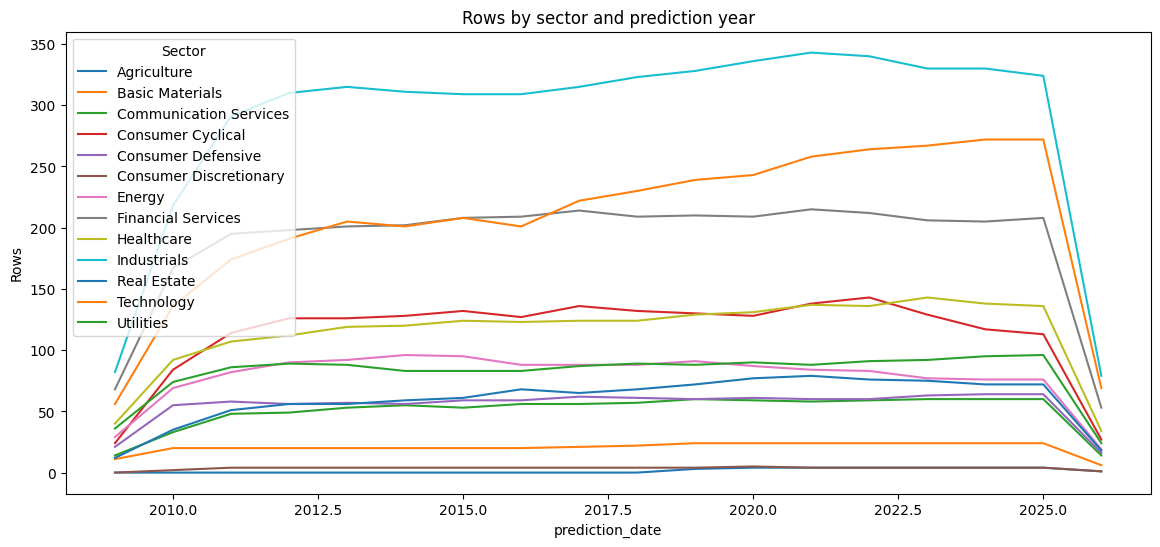

In [33]:
if 'Sector' in df.columns:
    sector_coverage = df.groupby('Sector', dropna=False).agg(
        rows=('adsh', 'count'),
        firms=('cik', 'nunique'),
        tickers=('ticker', 'nunique'),
        first_prediction_date=('prediction_date', 'min'),
        last_prediction_date=('prediction_date', 'max'),
    ).sort_values('rows', ascending=False)
    display(sector_coverage)

if {'prediction_date', 'Sector'}.issubset(df.columns):
    sector_year = pd.crosstab(df['prediction_date'].dt.year, df['Sector'])
    display(sector_year.tail(20))
    sector_year.plot(figsize=(14, 6), title='Rows by sector and prediction year')
    plt.ylabel('Rows')
    plt.show()

## 9. Target Distributions

In [34]:
target_summary = []
for target in TARGET_COLS:
    s = pd.to_numeric(df[target], errors='coerce')
    known = s.notna()
    target_summary.append({
        'target': target,
        'known_rows': int(known.sum()),
        'unknown_rows': int((~known).sum()),
        'positive_rows': int(s.fillna(0).sum()),
        'positive_share_known': float(s.mean()) if known.any() else np.nan,
    })

target_summary = pd.DataFrame(target_summary).sort_values('target')
display(target_summary)

if 'manual_temporal_split' in df.columns:
    split_target_rows = []
    for split, g in df.groupby('manual_temporal_split'):
        for target in TARGET_COLS:
            s = pd.to_numeric(g[target], errors='coerce')
            split_target_rows.append({
                'split': split,
                'target': target,
                'rows': len(g),
                'known_rows': int(s.notna().sum()),
                'unknown_rows': int(s.isna().sum()),
                'positive_rows': int(s.fillna(0).sum()),
                'positive_share_known': float(s.mean()) if s.notna().any() else np.nan,
            })
    split_target_summary = pd.DataFrame(split_target_rows)
    display(split_target_summary.sort_values(['target', 'split']))

,target,known_rows,unknown_rows,positive_rows,positive_share_known
3,broad_distress_next_4q,22713,0,200,0.0088
0,distress_next_2q,22713,0,81,0.0036
1,distress_next_4q,22713,0,170,0.0075
2,distress_next_8q,22713,0,339,0.0149
9,formal_distress_firm,22713,0,1385,0.0610
4,healthy_current,22713,0,10187,0.4485
10,near_distress_firm,22713,0,217,0.0096
8,post_event_flag,22713,0,390,0.0172
5,success_profitability_next_4q,21506,1207,18849,0.8765
7,success_quality_next_4q,14526,8187,6841,0.4709


,split,target,rows,known_rows,unknown_rows,positive_rows,positive_share_known
3,test,broad_distress_next_4q,4431,4431,0,84,0.0190
14,train,broad_distress_next_4q,12084,12084,0,58,0.0048
25,unused,broad_distress_next_4q,1814,1814,0,0,0.0000
36,validation,broad_distress_next_4q,4384,4384,0,58,0.0132
0,test,distress_next_2q,4431,4431,0,33,0.0074
11,train,distress_next_2q,12084,12084,0,27,0.0022
22,unused,distress_next_2q,1814,1814,0,0,0.0000
33,validation,distress_next_2q,4384,4384,0,21,0.0048
1,test,distress_next_4q,4431,4431,0,64,0.0144
12,train,distress_next_4q,12084,12084,0,58,0.0048


In [35]:
for target in ['distress_next_4q', 'success_resilience_next_4q', 'success_quality_next_4q']:
    if target not in df.columns or 'Sector' not in df.columns:
        continue
    print('\nTarget by sector:', target)
    target_by_sector = df.groupby('Sector', dropna=False)[target].agg(
        rows='size',
        known_rows=lambda s: int(pd.to_numeric(s, errors='coerce').notna().sum()),
        positives=lambda s: int(pd.to_numeric(s, errors='coerce').fillna(0).sum()),
        positive_share_known=lambda s: float(pd.to_numeric(s, errors='coerce').mean()) if pd.to_numeric(s, errors='coerce').notna().any() else np.nan,
    ).sort_values('positive_share_known', ascending=False)
    display(target_by_sector)


Target by sector: distress_next_4q


,rows,known_rows,positives,positive_share_known
Sector,,,,
Energy,1410,1410,41,0.0291
Consumer Cyclical,2054,2054,56,0.0273
Industrials,5193,5193,30,0.0058
Communication Services,904,904,5,0.0055
Healthcare,2069,2069,10,0.0048
Real Estate,1072,1072,5,0.0047
Utilities,1462,1462,5,0.0034
Financial Services,3389,3389,9,0.0027
Technology,3708,3708,9,0.0024



Target by sector: success_resilience_next_4q


,rows,known_rows,positives,positive_share_known
Sector,,,,
Basic Materials,368,276,257,0.9312
Real Estate,1072,973,853,0.8767
Utilities,1462,410,355,0.8659
Healthcare,2069,1045,833,0.7971
Industrials,5193,2977,2325,0.7810
Technology,3708,2484,1786,0.7190
Consumer Discretionary,64,61,43,0.7049
Consumer Defensive,992,608,403,0.6628
Energy,1410,933,596,0.6388



Target by sector: success_quality_next_4q


,rows,known_rows,positives,positive_share_known
Sector,,,,
Healthcare,2069,1045,757,0.7244
Basic Materials,368,276,185,0.6703
Industrials,5193,2977,1951,0.6554
Technology,3708,2484,1515,0.6099
Consumer Defensive,992,608,313,0.5148
Consumer Discretionary,64,61,31,0.5082
Communication Services,904,425,198,0.4659
Energy,1410,933,396,0.4244
Consumer Cyclical,2054,1193,459,0.3847


## 10. Missingness Diagnostics

,missing_share
days_from_period_to_event,0.9295
event_year,0.9295
event_date,0.9295
event_type,0.9295
event_label,0.9295
verification_status,0.9295
days_to_event,0.9295
long_term_debt,0.9217
r_and_d_intensity,0.7494
r_and_d_expense,0.7449


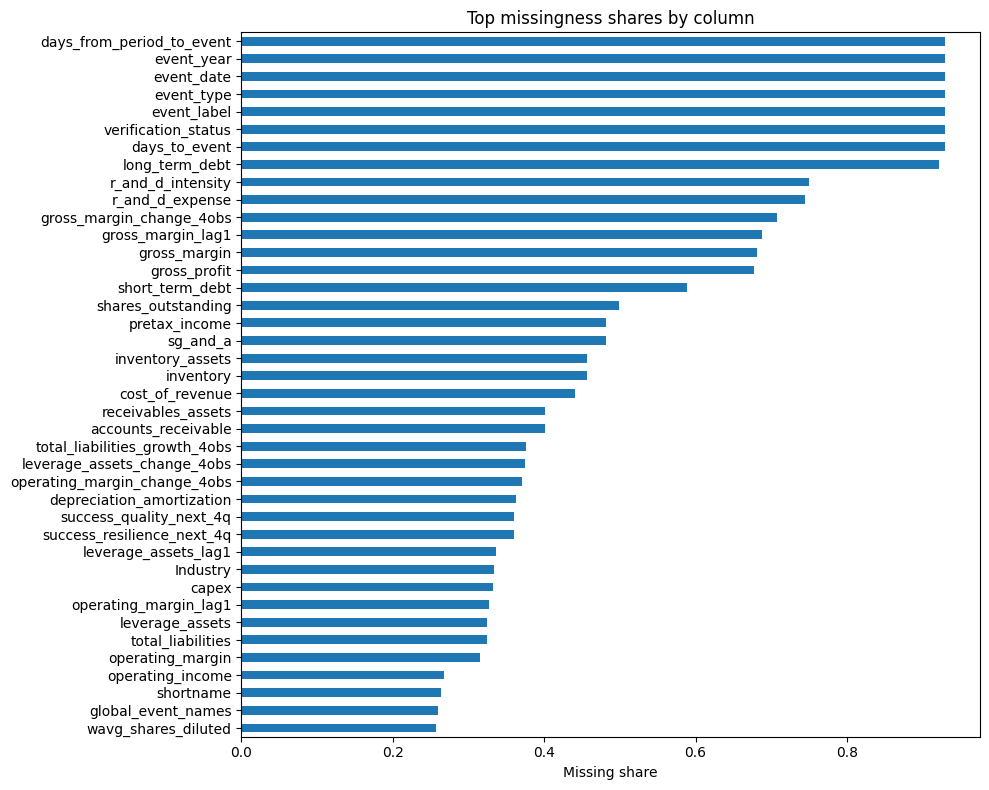

In [36]:
missing = df.isna().mean().sort_values(ascending=False)
display(missing.head(60).to_frame('missing_share'))

plt.figure(figsize=(10, 8))
missing.head(40).sort_values().plot(kind='barh')
plt.title('Top missingness shares by column')
plt.xlabel('Missing share')
plt.tight_layout()
plt.show()

In [37]:
CORE_ACCOUNTING_COLS = [col for col in [
    'total_assets', 'total_liabilities', 'total_equity', 'current_assets', 'current_liabilities',
    'cash_equivalents', 'total_revenue', 'gross_profit', 'operating_income', 'net_income',
    'cash_flow_operating', 'capex'
] if col in df.columns]

RATIO_COLS = [col for col in [
    'leverage_assets', 'equity_assets', 'current_ratio', 'cash_assets', 'net_margin',
    'operating_margin', 'gross_margin', 'roa', 'r_and_d_intensity', 'inventory_assets', 'receivables_assets'
] if col in df.columns]

TREND_COLS = [col for col in df.columns if col.endswith('_lag1') or col.endswith('_growth_4obs') or col.endswith('_change_4obs') or col == 'net_income_negative_count_prior_4obs']
MACRO_COLS = [col for col in df.columns if col in {
    'BAMLH0A0HYM2', 'FEDFUNDS', 'GDPC1', 'GS10', 'INDPRO', 'NFCI', 'UNRATE', 'USEPUINDXD',
    'VIXCLS', 'T10Y2Y', 'T10Y3M', 'DCOILWTICO', 'DTWEXBGS', 'CPIAUCSL', 'PPIACO',
    'PAYEMS', 'RSAFS', 'HOUST', 'BUSLOANS', 'DRTSCILM'
} or col.endswith('_yoy_pct')]
REGIME_COLS = [col for col in df.columns if col.endswith('_regime')]
EVENT_COLS = [col for col in df.columns if col.startswith('global_event_')]

families = {
    'core_accounting': CORE_ACCOUNTING_COLS,
    'ratios': RATIO_COLS,
    'trends': TREND_COLS,
    'macro': MACRO_COLS,
    'regimes': REGIME_COLS,
    'global_events': EVENT_COLS,
    'targets': TARGET_COLS,
}

family_rows = []
for family, cols in families.items():
    if not cols:
        continue
    values = df[cols]
    family_rows.append({
        'family': family,
        'columns': len(cols),
        'cell_missing_share': float(values.isna().sum().sum() / values.size),
        'columns_all_missing': int((values.isna().mean() == 1).sum()),
        'columns_no_missing': int((values.isna().mean() == 0).sum()),
    })
display(pd.DataFrame(family_rows).sort_values('cell_missing_share', ascending=False))

,family,columns,cell_missing_share,columns_all_missing,columns_no_missing
1,ratios,11,0.2955,0,0
2,trends,21,0.2354,0,1
0,core_accounting,12,0.1865,0,0
6,targets,11,0.0704,0,8
5,global_events,27,0.0096,0,26
3,macro,30,0.0030,0,19
4,regimes,10,0.0000,0,10


manual_temporal_split,test,train,unused,validation
r_and_d_intensity,0.7098,0.7765,0.6940,0.7379
gross_margin,0.6791,0.6807,0.6770,0.6898
gross_profit,0.6723,0.6795,0.6714,0.6797
inventory_assets,0.4518,0.4575,0.4598,0.4578
receivables_assets,0.3803,0.4177,0.3903,0.3841
capex,0.3191,0.3419,0.3269,0.3248
success_resilience_next_4q,0.2959,0.3489,0.7144,0.3111
success_quality_next_4q,0.2959,0.3489,0.7144,0.3111
operating_margin,0.2956,0.3271,0.2850,0.3125
leverage_assets,0.2896,0.3474,0.2850,0.3109


,total_assets,total_liabilities,total_equity,current_assets,current_liabilities,cash_equivalents,total_revenue,gross_profit,operating_income,net_income,cash_flow_operating,capex,leverage_assets,equity_assets,current_ratio,cash_assets,net_margin,operating_margin,gross_margin,roa,r_and_d_intensity,inventory_assets,receivables_assets,distress_next_2q,distress_next_4q,distress_next_8q,broad_distress_next_4q,healthy_current,success_profitability_next_4q,success_resilience_next_4q,success_quality_next_4q,post_event_flag,formal_distress_firm,near_distress_firm
Sector,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Agriculture,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.1071,1.0000,1.0000,0.0000,0.0000,0.0000
Basic Materials,0.0027,0.2228,0.0000,0.0109,0.0109,0.0027,0.1495,0.8179,0.3668,0.0000,0.2255,0.5435,0.2228,0.0027,0.0109,0.0027,0.1495,0.4185,0.8179,0.0027,0.6549,0.3098,0.0109,0.0000,0.0000,0.0000,0.0000,0.0000,0.0489,0.2500,0.2500,0.0000,0.0000,0.0000
Communication Services,0.0000,0.4934,0.0000,0.0000,0.0000,0.0000,0.0033,0.8407,0.0343,0.0088,0.1648,0.3761,0.4934,0.0000,0.0000,0.0000,0.0088,0.0343,0.8407,0.0088,0.6836,0.7113,0.2611,0.0000,0.0000,0.0000,0.0000,0.0000,0.0597,0.5299,0.5299,0.0000,0.0000,0.0000
Consumer Cyclical,0.0015,0.3832,0.0044,0.0472,0.0472,0.0083,0.0657,0.4932,0.1762,0.0029,0.1796,0.1719,0.3832,0.0044,0.0472,0.0088,0.0657,0.2089,0.4971,0.0034,0.9129,0.2926,0.5204,0.0000,0.0000,0.0000,0.0000,0.0000,0.0570,0.4192,0.4192,0.0000,0.0000,0.0000
Consumer Defensive,0.0010,0.3538,0.0000,0.0010,0.0010,0.0655,0.0343,0.3538,0.0464,0.0030,0.1391,0.2782,0.3538,0.0010,0.0010,0.0655,0.0343,0.0766,0.3841,0.0040,1.0000,0.0685,0.4395,0.0000,0.0000,0.0000,0.0000,0.0000,0.0484,0.3871,0.3871,0.0000,0.0000,0.0000


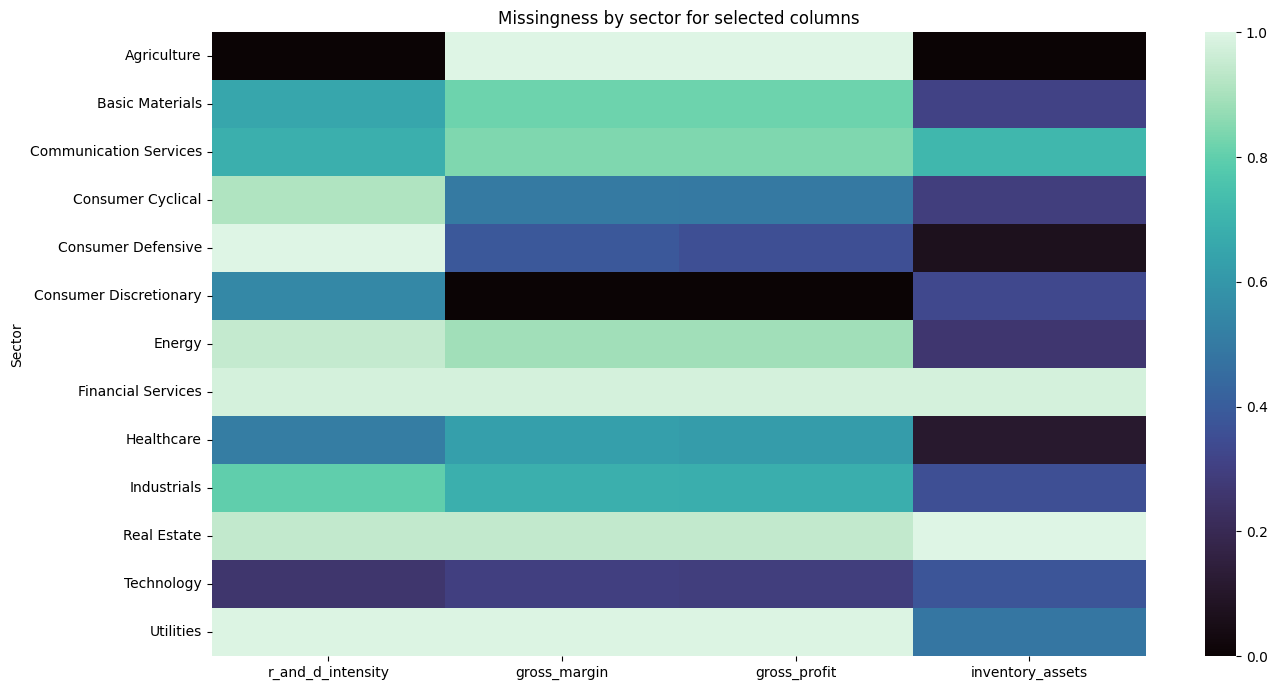

In [38]:
important_missing_cols = [col for col in CORE_ACCOUNTING_COLS + RATIO_COLS + TARGET_COLS if col in df.columns]
if {'manual_temporal_split'}.issubset(df.columns) and important_missing_cols:
    miss_by_split = df.groupby('manual_temporal_split')[important_missing_cols].apply(lambda x: x.isna().mean()).T
    display(miss_by_split.sort_values(miss_by_split.columns.tolist(), ascending=False).head(60))

if {'Sector'}.issubset(df.columns) and important_missing_cols:
    miss_by_sector = df.groupby('Sector')[important_missing_cols].apply(lambda x: x.isna().mean())
    display(miss_by_sector.head())
    top_cols = missing[missing > 0].head(20).index.intersection(important_missing_cols)
    if len(top_cols) and HAS_SEABORN:
        plt.figure(figsize=(14, 7))
        sns.heatmap(miss_by_sector[top_cols], cmap='mako', annot=False)
        plt.title('Missingness by sector for selected columns')
        plt.tight_layout()
        plt.show()

## 11. Total Liabilities Manual Check

In [39]:
if 'total_liabilities' in df.columns:
    tl_missing = df['total_liabilities'].isna()
    print('total_liabilities missing rows:', int(tl_missing.sum()))
    print('total_liabilities missing share:', float(tl_missing.mean()))
    
    group_cols = [col for col in ['manual_temporal_split', 'Sector', 'form', 'afs', 'sec_zip', 'cohort', 'success_resilience_next_4q', 'distress_next_4q'] if col in df.columns]
    tl_rows = []
    for col in group_cols:
        for value, g in df.groupby(col, dropna=False):
            tl_rows.append({
                'grouping': col,
                'value': value,
                'rows': len(g),
                'missing_rows': int(g['total_liabilities'].isna().sum()),
                'missing_share': float(g['total_liabilities'].isna().mean()),
            })
    display(pd.DataFrame(tl_rows).sort_values(['grouping', 'missing_share'], ascending=[True, False]).head(120))

total_liabilities missing rows: 7357
total_liabilities missing share: 0.32391141636948


,grouping,value,rows,missing_rows,missing_share
4,Sector,Agriculture,28,28,1.0000
16,Sector,Utilities,1462,1023,0.6997
6,Sector,Communication Services,904,446,0.4934
12,Sector,Healthcare,2069,960,0.4640
13,Sector,Industrials,5193,2055,0.3957
7,Sector,Consumer Cyclical,2054,787,0.3832
8,Sector,Consumer Defensive,992,351,0.3538
10,Sector,Energy,1410,416,0.2950
15,Sector,Technology,3708,1077,0.2905
5,Sector,Basic Materials,368,82,0.2228


In [40]:
needed = {'total_assets', 'total_equity', 'total_liabilities'}
if needed.issubset(df.columns):
    deriv = df[['ticker', 'cik', 'prediction_date', 'total_assets', 'total_equity', 'total_liabilities']].copy()
    deriv['derived_total_liabilities'] = deriv['total_assets'] - deriv['total_equity']
    deriv['reported_available'] = deriv['total_liabilities'].notna()
    deriv['derivation_available'] = deriv['total_assets'].notna() & deriv['total_equity'].notna()
    deriv['abs_diff'] = (deriv['derived_total_liabilities'] - deriv['total_liabilities']).abs()
    deriv['rel_diff'] = deriv['abs_diff'] / deriv['total_liabilities'].abs().replace(0, np.nan)
    both = deriv['reported_available'] & deriv['derivation_available']
    fill_candidate = deriv['derivation_available'] & ~deriv['reported_available']
    print('Rows where derivation available but reported total_liabilities missing:', int(fill_candidate.sum()))
    print('Rows with both reported and derivable:', int(both.sum()))
    display(deriv.loc[both, ['abs_diff', 'rel_diff']].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]))
    display(deriv.loc[both].sort_values('rel_diff', ascending=False).head(30))
    print('Manual rule reminder: do not fill total_liabilities silently unless you decide and document a parser rule.')

Rows where derivation available but reported total_liabilities missing: 7252
Rows with both reported and derivable: 15290


,abs_diff,rel_diff
count,"15,290.0000","15,289.0000"
mean,"4,003,030,355.4833",2.1248
std,"18,677,244,332.5625",156.1894
min,0.0000,0.0000
1%,0.0000,0.0000
5%,0.0000,0.0000
50%,"574,776,000.0000",0.0440
95%,"15,867,550,000.0000",0.5574
99%,"61,191,360,000.0001",1.9570
max,"1,024,293,000,000.0000","13,510.1464"


,ticker,cik,prediction_date,total_assets,total_equity,total_liabilities,derived_total_liabilities,reported_available,derivation_available,abs_diff,rel_diff
3527,CANO,1800682,2020-11-10,"692,122,866.0000","5,000,006.0000","50,856.0000","687,122,860.0000",True,True,"687,072,004.0000","13,510.1464"
3528,CANO,1800682,2021-03-29,"691,531,547.0000","5,000,001.0000","50,856.0000","686,531,546.0000",True,True,"686,480,690.0000","13,498.5192"
17596,RIDE,1759546,2019-08-13,"283,017,569.0000","5,000,005.0000","96,650.0000","278,017,564.0000",True,True,"277,920,914.0000","2,875.5397"
3526,CANO,1800682,2020-08-13,"45,568.0000","5,000,006.0000","50,856.0000","-4,954,438.0000",True,True,"5,005,294.0000",98.4209
17601,RIDE,1759546,2021-03-25,"767,219,000.0000",0.0000,"24,990,000.0000","767,219,000.0000",True,True,"742,229,000.0000",29.7010
21704,WE,1813756,2020-11-13,"484,512,579.0000","5,000,008.0000","17,055,841.0000","479,512,571.0000",True,True,"462,456,730.0000",27.1143
21705,WE,1813756,2021-03-24,"484,520,512.0000","5,000,010.0000","17,116,262.0000","479,520,502.0000",True,True,"462,404,240.0000",27.0155
17599,RIDE,1759546,2020-05-14,"285,407,440.0000","5,000,005.0000","10,121,643.0000","280,407,435.0000",True,True,"270,285,792.0000",26.7037
17600,RIDE,1759546,2020-08-13,"285,275,830.0000","5,000,005.0000","10,373,276.0000","280,275,825.0000",True,True,"269,902,549.0000",26.0190
17229,PTRA,1820630,2020-11-16,"279,941,343.0000","5,000,008.0000","10,814,595.0000","274,941,335.0000",True,True,"264,126,740.0000",24.4232


Manual rule reminder: do not fill total_liabilities silently unless you decide and document a parser rule.


## 12. Numeric Sanity Checks and Outliers

In [41]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
audit_numeric_cols = [col for col in CORE_ACCOUNTING_COLS + RATIO_COLS + TREND_COLS + MACRO_COLS if col in numeric_cols]

numeric_summary = df[audit_numeric_cols].describe(percentiles=[0.001, 0.01, 0.05, 0.5, 0.95, 0.99, 0.999]).T
numeric_summary['missing_share'] = df[audit_numeric_cols].isna().mean()
numeric_summary['zero_share'] = (df[audit_numeric_cols] == 0).mean()
numeric_summary['negative_share'] = (df[audit_numeric_cols] < 0).mean()
display(numeric_summary.sort_values('missing_share', ascending=False).head(80))

if EXPORT_RESULTS:
    EXPORT_DIR.mkdir(parents=True, exist_ok=True)
    numeric_summary.to_csv(EXPORT_DIR / 'firm_panel_numeric_summary.csv')

,count,mean,std,min,0.1%,1%,5%,50%,95%,99%,99.9%,max,missing_share,zero_share,negative_share
r_and_d_intensity,"5,691.0000",0.1676,1.2038,-59.6667,-4.4484,-0.2504,0.0068,0.1100,0.4092,1.4072,13.8606,25.9098,0.7494,0.0000,0.0068
gross_margin_change_4obs,"6,648.0000",0.0033,1.2628,-45.4834,-11.9886,-1.4641,-0.2805,0.0000,0.2913,1.5089,10.9033,44.6122,0.7073,0.0134,0.1363
gross_margin_lag1,"7,101.0000",0.3726,7.5748,-611.8333,-8.6177,-0.1407,0.0569,0.4697,0.8768,1.4640,7.6655,45.5177,0.6874,0.0000,0.0048
gross_margin,"7,227.0000",0.4849,0.9377,-27.7114,-7.2836,-0.1300,0.0570,0.4705,0.8779,1.5035,9.6738,45.5177,0.6818,0.0000,0.0048
gross_profit,"7,325.0000","2,055,492,079.9768","4,351,514,197.6881","-24,834,000,000.0000","-2,595,796,000.0000","-32,618,920.0000","58,692,800.0000","816,000,000.0000","8,200,200,000.0000","19,681,000,000.0000","47,833,000,000.0000","86,335,000,000.0000",0.6775,0.0000,0.0041
inventory_assets,"12,342.0000",0.0953,0.0970,0.0001,0.0003,0.0013,0.0050,0.0682,0.3027,0.4387,0.6653,0.7949,0.4566,0.0000,0.0000
receivables_assets,"13,588.0000",0.0852,0.0685,0.0000,0.0013,0.0060,0.0141,0.0702,0.2086,0.3198,0.6290,0.9130,0.4018,0.0000,0.0000
total_liabilities_growth_4obs,"14,186.0000",0.1471,0.5696,-0.8792,-0.7580,-0.3137,-0.1219,0.0421,0.6807,1.8744,5.4344,30.8250,0.3754,0.0359,0.1740
leverage_assets_change_4obs,"14,193.0000",-0.0057,1.0026,-83.5868,-1.3213,-0.4296,-0.1532,0.0000,0.1904,0.4778,1.2412,3.2631,0.3751,0.0084,0.3090
operating_margin_change_4obs,"14,279.0000",0.0146,2.1386,-91.6054,-13.1145,-1.7208,-0.2659,0.0000,0.2939,1.6651,16.3368,91.7601,0.3713,0.0278,0.2995


In [42]:
nonnegative_expected = [col for col in [
    'total_assets', 'total_liabilities', 'current_assets', 'current_liabilities', 'cash_equivalents',
    'inventory', 'accounts_receivable', 'ppe_net', 'shares_outstanding', 'wavg_shares_basic', 'wavg_shares_diluted'
] if col in df.columns]

negative_rows = []
for col in nonnegative_expected:
    s = pd.to_numeric(df[col], errors='coerce')
    negative_rows.append({
        'column': col,
        'negative_rows': int((s < 0).sum()),
        'negative_share_known': float((s < 0).sum() / s.notna().sum()) if s.notna().any() else np.nan,
        'min': s.min(),
        'p01': s.quantile(0.01),
    })
display(pd.DataFrame(negative_rows).sort_values('negative_rows', ascending=False))

for col in nonnegative_expected:
    bad = df[pd.to_numeric(df[col], errors='coerce') < 0]
    if len(bad):
        print('\nNegative sample:', col)
        display(bad[['ticker', 'cik', 'form', 'period_date', 'filed_date', col, 'sec_zip']].head(20))

,column,negative_rows,negative_share_known,min,p01
3,current_liabilities,1,0.0001,"-3,765,894,000.0000","68,620,000.0000"
0,total_assets,0,0.0000,0.0000,"400,063,410.0000"
1,total_liabilities,0,0.0000,0.0000,"111,425,462.7000"
2,current_assets,0,0.0000,10.0000,"182,801,000.0000"
4,cash_equivalents,0,0.0000,0.0000,"9,838,910.0000"
5,inventory,0,0.0000,"2,104.0000","9,108,000.0000"
6,accounts_receivable,0,0.0000,"2,000.0000","18,395,760.0000"
7,ppe_net,0,0.0000,"8,033.0000","30,527,000.0000"
8,shares_outstanding,0,0.0000,0.0000,"21,683,802.0000"
9,wavg_shares_basic,0,0.0000,7.0000,"1,236,775.1100"



Negative sample: current_liabilities


,ticker,cik,form,period_date,filed_date,current_liabilities,sec_zip
7630,ETR,65984,10-Q/A,2009-06-30,2009-09-04,"-3,765,894,000.0000",2009q3


In [43]:
ratio_extreme_rows = []
for col in RATIO_COLS + [c for c in TREND_COLS if c in df.columns]:
    s = pd.to_numeric(df[col], errors='coerce')
    ratio_extreme_rows.append({
        'column': col,
        'known_rows': int(s.notna().sum()),
        'abs_gt_10': int((s.abs() > 10).sum()),
        'abs_gt_100': int((s.abs() > 100).sum()),
        'min': s.min(),
        'p01': s.quantile(0.01),
        'median': s.median(),
        'p99': s.quantile(0.99),
        'max': s.max(),
    })
ratio_extremes = pd.DataFrame(ratio_extreme_rows).sort_values(['abs_gt_100', 'abs_gt_10'], ascending=False)
display(ratio_extremes.head(80))

EXTREME_COLUMN = 'roa'
if EXTREME_COLUMN in df.columns:
    s = pd.to_numeric(df[EXTREME_COLUMN], errors='coerce')
    sample = df.loc[s.abs() > s.abs().quantile(0.995), ['ticker', 'cik', 'Sector', 'period_date', 'prediction_date', EXTREME_COLUMN, 'net_income', 'total_assets', 'form', 'sec_zip']]
    display(sample.sort_values(EXTREME_COLUMN).head(20))
    display(sample.sort_values(EXTREME_COLUMN, ascending=False).head(20))

,column,known_rows,abs_gt_10,abs_gt_100,min,p01,median,p99,max
16,operating_margin_lag1,15290,37,4,-582.3333,-1.5885,0.1573,0.9365,144.1587
15,net_margin_lag1,19943,44,3,-346.6667,-1.3806,0.1036,0.9241,415.2857
17,gross_margin_lag1,7101,13,2,-611.8333,-0.1407,0.4697,1.4640,45.5177
12,leverage_assets_lag1,15073,4,2,0.0001,0.1146,0.6348,1.4166,"2,564.7473"
11,roa_lag1,22219,2,1,-805.9783,-0.1033,0.0129,0.0918,8.1349
20,cash_equivalents_growth_4obs,20147,176,0,-1.0000,-0.8595,0.0000,8.7942,96.5246
2,current_ratio,19038,86,0,-1.3703,0.3177,1.3333,7.7450,69.2878
13,current_ratio_lag1,18707,85,0,-1.3703,0.3176,1.3371,7.7450,69.2878
18,total_revenue_growth_4obs,18722,73,0,-66.0196,-1.6088,0.0265,2.5208,78.4102
28,net_margin_change_4obs,18703,62,0,-92.3223,-1.6551,0.0000,1.6679,91.5348


,ticker,cik,Sector,period_date,prediction_date,roa,net_income,total_assets,form,sec_zip
3529,CANO,1800682,Healthcare,2020-12-31,2021-04-29,-56.1831,"-2,560,151.0000","45,568.0000",10-K/A,2021q2
17618,RIDE,1759546,Consumer Cyclical,2024-12-31,2025-03-28,-3.6499,"-336,409,000.0000","92,169,000.0000",10-K,2025q1
20615,UCIHQ,1022646,Energy,2016-12-31,2017-02-22,-3.3661,"-3,204,640,000.0000","952,038,975.0000",10-K,2017q1
17616,RIDE,1759546,Consumer Cyclical,2024-06-30,2024-08-13,-2.4248,"-154,491,000.0000","63,713,000.0000",10-Q,2024q3
17615,RIDE,1759546,Consumer Cyclical,2024-03-31,2024-05-14,-2.1699,"-171,719,000.0000","79,137,000.0000",10-Q,2024q2
15088,NVAX,1000694,Healthcare,2020-12-31,2021-03-01,-1.8351,"-317,395,000.0000","172,957,000.0000",10-K,2021q1
3037,BRDS,1861449,Consumer Cyclical,2023-06-30,2023-08-09,-1.6425,"-320,316,000.0000","195,013,000.0000",10-Q,2023q3
3038,BRDS,1861449,Consumer Cyclical,2023-09-30,2023-11-14,-1.4400,"-320,316,000.0000","222,437,000.0000",10-Q,2023q4
17613,RIDE,1759546,Consumer Cyclical,2023-09-30,2023-11-14,-1.4303,"-154,430,000.0000","107,972,000.0000",10-Q,2023q4
4148,CHK,895126,Energy,2021-03-31,2021-05-13,-1.2602,"-8,297,000,000.0000","6,584,000,000.0000",10-Q,2021q2


,ticker,cik,Sector,period_date,prediction_date,roa,net_income,total_assets,form,sec_zip
17597,RIDE,1759546,Real Estate,2019-09-30,2019-11-14,8.1349,"976,190.0000","120,000.0000",10-Q,2019q4
17595,RIDE,1759546,Real Estate,2019-03-31,2019-05-15,2.1908,"262,896.0000","120,000.0000",10-Q,2019q2
4151,CHK,895126,Energy,2021-12-31,2022-02-24,0.8184,"9,010,000,000.0000","11,009,000,000.0000",10-K,2022q1
21977,WLTGQ,837173,Energy,2012-12-31,2013-03-01,0.8162,"1,353,002,000.0000","1,657,765,000.0000",10-K,2013q1
15167,NVDA,1045810,Technology,2024-01-31,2024-02-21,0.6509,"26,806,000,000.0000","41,182,000,000.0000",10-K,2024q1
14852,NPCMQ,1458891,Energy,2021-12-31,2022-02-17,0.6066,"1,257,721,000.0000","2,073,442,000.0000",10-K,2022q1
6777,EBAY,1065088,Industrials,2022-12-31,2023-02-23,0.5840,"15,549,000,000.0000","26,626,000,000.0000",10-K,2023q1
6771,EBAY,1065088,Industrials,2021-06-30,2021-08-12,0.5559,"10,734,000,000.0000","19,310,000,000.0000",10-Q,2021q3
6781,EBAY,1065088,Industrials,2023-12-31,2024-02-28,0.5349,"11,565,000,000.0000","21,620,000,000.0000",10-K,2024q1
3285,BTUUQ,1064728,Energy,2020-12-31,2021-02-23,0.5153,"2,404,900,000.0000","4,667,100,000.0000",10-K,2021q1


## 13. Accounting Identity and Ratio Consistency Checks

In [44]:
consistency_rows = []

if {'total_assets', 'total_liabilities', 'total_equity'}.issubset(df.columns):
    resid = df['total_assets'] - df['total_liabilities'] - df['total_equity']
    denom = df['total_assets'].abs().replace(0, np.nan)
    rel_resid = resid.abs() / denom
    consistency_rows.append({'check': 'assets - liabilities - equity relative residual > 5%', 'rows': int((rel_resid > 0.05).sum())})
    display(pd.DataFrame({
        'residual': resid,
        'relative_residual': rel_resid,
    }).describe(percentiles=[0.5, 0.9, 0.95, 0.99]))
    bad_identity = df.loc[rel_resid > 0.05, ['ticker', 'cik', 'period_date', 'prediction_date', 'total_assets', 'total_liabilities', 'total_equity', 'form', 'sec_zip']].copy()
    bad_identity['identity_residual'] = resid.loc[bad_identity.index]
    bad_identity['relative_residual'] = rel_resid.loc[bad_identity.index]
    display(bad_identity.sort_values('relative_residual', ascending=False).head(40))

if {'total_liabilities', 'total_assets', 'leverage_assets'}.issubset(df.columns):
    computed = df['total_liabilities'] / df['total_assets'].replace(0, np.nan)
    diff = (computed - df['leverage_assets']).abs()
    consistency_rows.append({'check': 'leverage_assets recomputation diff > 1e-6', 'rows': int((diff > 1e-6).sum())})

if {'total_equity', 'total_assets', 'equity_assets'}.issubset(df.columns):
    computed = df['total_equity'] / df['total_assets'].replace(0, np.nan)
    diff = (computed - df['equity_assets']).abs()
    consistency_rows.append({'check': 'equity_assets recomputation diff > 1e-6', 'rows': int((diff > 1e-6).sum())})

if {'current_assets', 'current_liabilities', 'current_ratio'}.issubset(df.columns):
    computed = df['current_assets'] / df['current_liabilities'].replace(0, np.nan)
    diff = (computed - df['current_ratio']).abs()
    consistency_rows.append({'check': 'current_ratio recomputation diff > 1e-6', 'rows': int((diff > 1e-6).sum())})

display(pd.DataFrame(consistency_rows))

,residual,relative_residual
count,"15,290.0000","15,288.0000"
mean,"451,516,378.8825",0.2651
std,"19,096,095,820.8947",21.6616
min,"-1,024,293,000,000.0000",0.0000
50%,"68,252,000.0000",0.0271
90%,"3,756,735,800.0000",0.1645
95%,"8,467,000,000.0000",0.2660
99%,"38,137,660,000.0001",0.7866
max,"436,451,000,000.0000","2,673.4734"


,ticker,cik,period_date,prediction_date,total_assets,total_liabilities,total_equity,form,sec_zip,identity_residual,relative_residual
3529,CANO,1800682,2020-12-31,2021-04-29,"45,568.0000","116,870,405.0000","5,000,001.0000",10-K/A,2021q2,"-121,824,838.0000","2,673.4734"
3526,CANO,1800682,2020-06-30,2020-08-13,"45,568.0000","50,856.0000","5,000,006.0000",10-Q,2020q3,"-5,005,294.0000",109.8423
17597,RIDE,1759546,2019-09-30,2019-11-14,"120,000.0000","10,034,328.0000","23,350.0000",10-Q,2019q4,"-9,937,678.0000",82.8140
17595,RIDE,1759546,2019-03-31,2019-05-15,"120,000.0000","9,977,688.0000","23,350.0000",10-Q,2019q2,"-9,881,038.0000",82.3420
17602,RIDE,1759546,2020-12-31,2021-06-08,"33,546,000.0000","136,481,000.0000","630,738,000.0000",10-K/A,2021q2,"-733,673,000.0000",21.8707
17617,RIDE,1759546,2024-09-30,2024-11-13,"58,251,000.0000","45,865,000.0000","351,772,000.0000",10-Q,2024q4,"-339,386,000.0000",5.8263
17615,RIDE,1759546,2024-03-31,2024-05-14,"79,137,000.0000","38,017,000.0000","351,771,000.0000",10-Q,2024q2,"-310,651,000.0000",3.9255
17613,RIDE,1759546,2023-09-30,2023-11-14,"107,972,000.0000","70,280,000.0000","412,437,000.0000",10-Q,2023q4,"-374,745,000.0000",3.4708
17618,RIDE,1759546,2024-12-31,2025-03-28,"92,169,000.0000","45,865,000.0000","351,771,000.0000",10-K,2025q1,"-305,467,000.0000",3.3142
21977,WLTGQ,837173,2012-12-31,2013-03-01,"1,657,765,000.0000","4,719,991,000.0000","2,136,517,000.0000",10-K,2013q1,"-5,198,743,000.0000",3.1360


,check,rows
0,assets - liabilities - equity relative residua...,5246
1,leverage_assets recomputation diff > 1e-6,0
2,equity_assets recomputation diff > 1e-6,0
3,current_ratio recomputation diff > 1e-6,0


## 14. Correlation and Redundancy Checks

,left,right,spearman_corr
0,total_assets,total_liabilities,0.9730
2,total_liabilities,current_liabilities,0.9236
3,current_assets,current_liabilities,0.9073
4,leverage_assets,leverage_assets_lag1,0.9072
1,total_assets,current_liabilities,0.9019


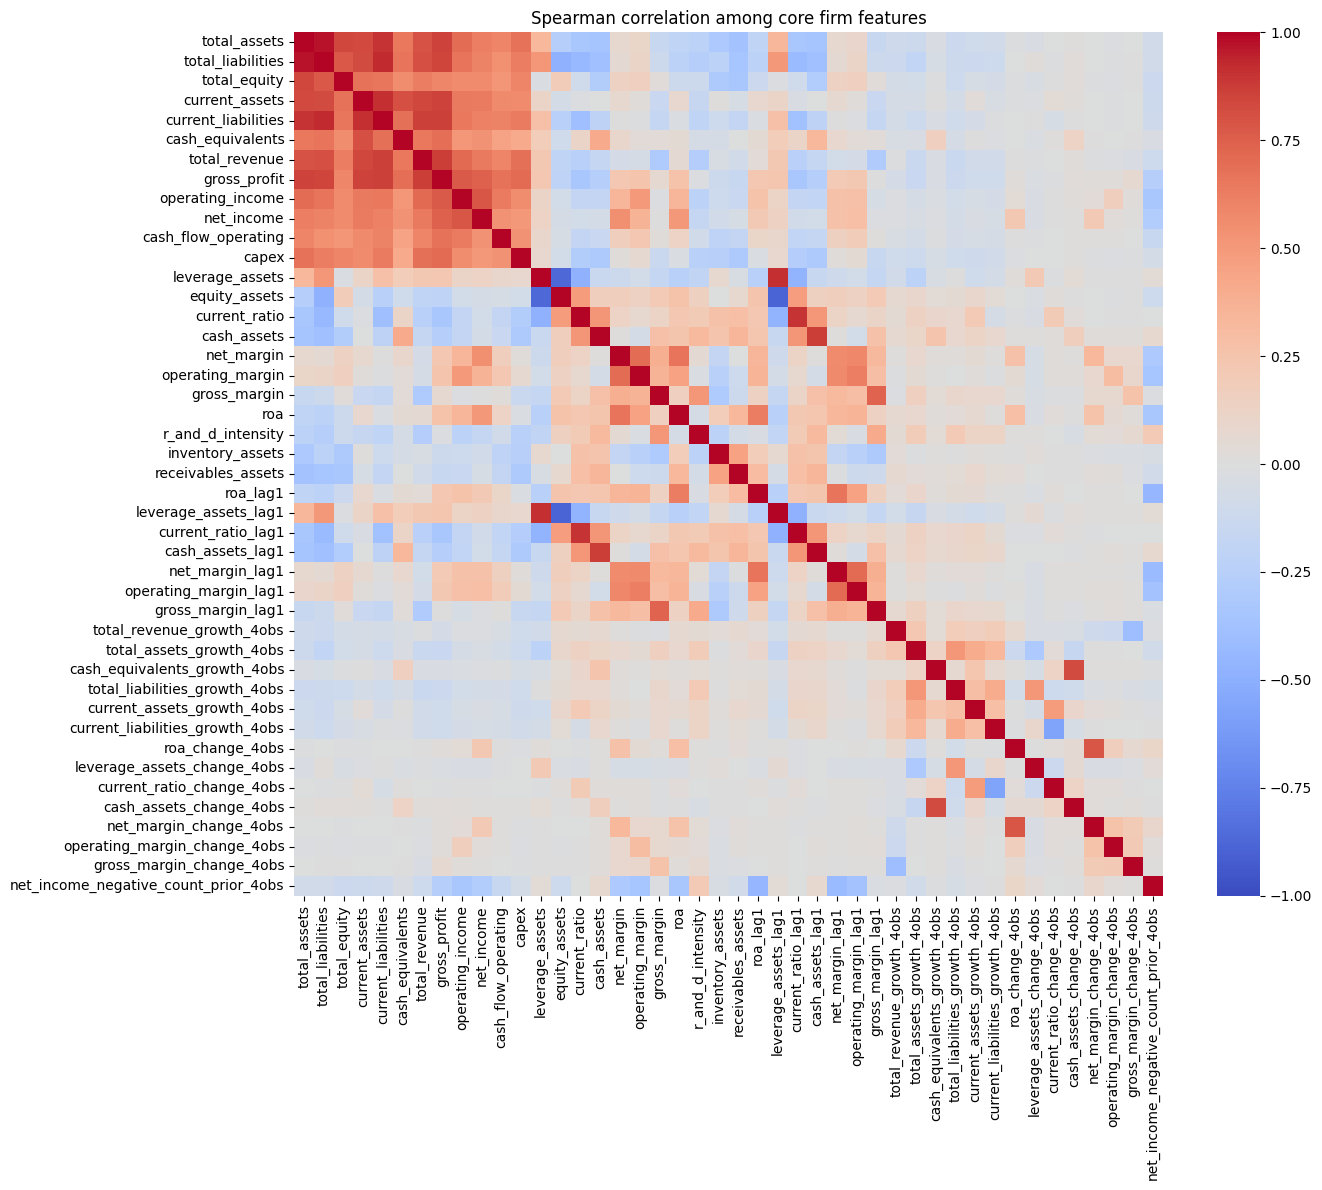

In [45]:
corr_cols = [col for col in CORE_ACCOUNTING_COLS + RATIO_COLS + TREND_COLS if col in df.columns]
corr_frame = df[corr_cols].copy()
corr = corr_frame.corr(method='spearman', min_periods=200)

pairs = []
cols = corr.columns.tolist()
for i, left in enumerate(cols):
    for right in cols[i+1:]:
        value = corr.loc[left, right]
        if pd.notna(value) and abs(value) >= 0.90:
            pairs.append({'left': left, 'right': right, 'spearman_corr': value})
high_corr_pairs = pd.DataFrame(pairs).sort_values('spearman_corr', key=lambda s: s.abs(), ascending=False)
display(high_corr_pairs.head(80))

if HAS_SEABORN and len(corr_cols) <= 60:
    plt.figure(figsize=(14, 12))
    sns.heatmap(corr, cmap='coolwarm', center=0, vmin=-1, vmax=1)
    plt.title('Spearman correlation among core firm features')
    plt.tight_layout()
    plt.show()
else:
    display(corr.head())

## 15. Simple Univariate Target Diagnostics

In [46]:
def univariate_target_table(data, target, features, min_known=200):
    rows = []
    y = pd.to_numeric(data[target], errors='coerce')
    base = data[y.notna()].copy()
    y = y.loc[base.index].astype(int)
    for feature in features:
        x = pd.to_numeric(base[feature], errors='coerce')
        valid = x.notna() & y.notna()
        if valid.sum() < min_known or y.loc[valid].nunique() < 2:
            continue
        x0 = x.loc[valid & (y == 0)]
        x1 = x.loc[valid & (y == 1)]
        pooled_std = x.loc[valid].std()
        rows.append({
            'target': target,
            'feature': feature,
            'known_rows': int(valid.sum()),
            'target_positive_rows': int(y.loc[valid].sum()),
            'target_positive_share': float(y.loc[valid].mean()),
            'median_if_0': x0.median(),
            'median_if_1': x1.median(),
            'mean_if_0': x0.mean(),
            'mean_if_1': x1.mean(),
            'standardized_mean_diff': (x1.mean() - x0.mean()) / pooled_std if pooled_std and pd.notna(pooled_std) else np.nan,
            'missing_share_if_0': float(x.loc[y == 0].isna().mean()),
            'missing_share_if_1': float(x.loc[y == 1].isna().mean()),
        })
    return pd.DataFrame(rows).sort_values('standardized_mean_diff', key=lambda s: s.abs(), ascending=False)

feature_candidates = [col for col in CORE_ACCOUNTING_COLS + RATIO_COLS + TREND_COLS + MACRO_COLS + REGIME_COLS + EVENT_COLS if col in df.columns]

for target in ['distress_next_4q', 'success_resilience_next_4q', 'success_quality_next_4q']:
    if target in df.columns:
        print('\nUnivariate diagnostics for:', target)
        uni = univariate_target_table(df, target, feature_candidates)
        display(uni.head(40))


Univariate diagnostics for: distress_next_4q


,target,feature,known_rows,target_positive_rows,target_positive_share,median_if_0,median_if_1,mean_if_0,mean_if_1,standardized_mean_diff,missing_share_if_0,missing_share_if_1
43,distress_next_4q,net_income_negative_count_prior_4obs,22713,170,0.0075,0.0000,3.0000,0.4807,2.6000,2.2127,0.0000,0.0000
13,distress_next_4q,equity_assets,22536,167,0.0074,0.3316,0.0895,0.3324,0.1004,-0.8013,0.0077,0.0176
21,distress_next_4q,inventory_assets,12342,93,0.0075,0.0681,0.1250,0.0948,0.1682,0.7570,0.4566,0.4529
97,distress_next_4q,global_event_monetary_inflation_severity,22713,170,0.0075,0.0000,0.0000,0.4205,1.4118,0.7086,0.0000,0.0000
96,distress_next_4q,global_event_monetary_inflation_count,22713,170,0.0075,0.0000,0.0000,0.0841,0.2824,0.7086,0.0000,0.0000
85,distress_next_4q,global_event_severity_sum,22713,170,0.0075,4.0000,5.0000,4.7240,6.9882,0.5906,0.0000,0.0000
31,distress_next_4q,total_assets_growth_4obs,21092,163,0.0077,0.0436,-0.0337,0.1189,0.5066,0.5611,0.0716,0.0412
84,distress_next_4q,global_event_count,22713,170,0.0075,1.0000,1.0000,1.1109,1.5765,0.5421,0.0000,0.0000
83,distress_next_4q,crisis_regime,22713,170,0.0075,0.0000,0.0000,0.2104,0.4294,0.5357,0.0000,0.0000
3,distress_next_4q,current_assets,19060,155,0.0081,"5,170,600,000.0000","1,001,200,000.0000","12,403,137,616.9292","1,671,697,729.0323",-0.5199,0.1614,0.0882



Univariate diagnostics for: success_resilience_next_4q


,target,feature,known_rows,target_positive_rows,target_positive_share,median_if_0,median_if_1,mean_if_0,mean_if_1,standardized_mean_diff,missing_share_if_0,missing_share_if_1
13,success_resilience_next_4q,equity_assets,14444,9503,0.6579,0.1229,0.4172,0.1781,0.4314,0.8245,0.0036,0.0067
43,success_resilience_next_4q,net_income_negative_count_prior_4obs,14526,9567,0.6586,0.0000,0.0000,0.9788,0.2656,-0.7275,0.0000,0.0000
1,success_resilience_next_4q,total_liabilities,14450,9525,0.6592,"26,078,200,000.0000","11,724,000,000.0000","210,612,788,251.1405","29,225,478,892.4193",-0.6013,0.0069,0.0044
0,success_resilience_next_4q,total_assets,14515,9564,0.6589,"33,427,500,000.0000","21,169,898,000.0000","234,113,633,144.5096","48,493,081,915.2230",-0.5604,0.0016,0.0003
21,success_resilience_next_4q,inventory_assets,6893,5042,0.7315,0.0672,0.0648,0.1134,0.0786,-0.3816,0.6267,0.4730
5,success_resilience_next_4q,cash_equivalents,13733,9249,0.6735,"1,501,200,000.0000","1,088,000,000.0000","15,004,447,858.3925","2,915,947,052.6681",-0.3664,0.0958,0.0332
12,success_resilience_next_4q,leverage_assets,14447,9523,0.6592,0.8669,0.5660,0.8566,0.5584,-0.2957,0.0071,0.0046
17,success_resilience_next_4q,operating_margin,9528,6832,0.7170,0.0874,0.1860,-0.1776,0.2332,0.2464,0.4563,0.2859
16,success_resilience_next_4q,net_margin,12926,8969,0.6939,0.0763,0.1205,-0.1481,0.1513,0.2082,0.2021,0.0625
20,success_resilience_next_4q,r_and_d_intensity,3917,2694,0.6878,0.1240,0.1031,0.3809,0.0848,-0.2055,0.7534,0.7184



Univariate diagnostics for: success_quality_next_4q


,target,feature,known_rows,target_positive_rows,target_positive_share,median_if_0,median_if_1,mean_if_0,mean_if_1,standardized_mean_diff,missing_share_if_0,missing_share_if_1
13,success_quality_next_4q,equity_assets,14444,6825,0.4725,0.2155,0.4390,0.2456,0.4555,0.6830,0.0086,0.0023
43,success_quality_next_4q,net_income_negative_count_prior_4obs,14526,6841,0.4709,0.0000,0.0000,0.7767,0.2084,-0.5796,0.0000,0.0000
1,success_quality_next_4q,total_liabilities,14450,6816,0.4717,"21,687,760,000.0000","9,470,000,000.0000","152,004,486,146.0034","22,775,589,986.5861",-0.4284,0.0066,0.0037
0,success_quality_next_4q,total_assets,14515,6841,0.4713,"32,483,642,000.0000","17,955,000,000.0000","174,850,138,675.6327","41,088,213,556.3302",-0.4038,0.0014,0.0000
22,success_quality_next_4q,receivables_assets,7854,4269,0.5435,0.0535,0.0776,0.0706,0.0909,0.2990,0.5335,0.3760
8,success_quality_next_4q,operating_income,10036,5379,0.5360,"196,246,000.0000","426,803,000.0000","454,017,390.6704","1,134,662,534.2166",0.2707,0.3940,0.2137
12,success_quality_next_4q,leverage_assets,14447,6815,0.4717,0.7626,0.5457,0.7727,0.5338,-0.2369,0.0069,0.0038
5,success_quality_next_4q,cash_equivalents,13733,6696,0.4876,"1,170,000,000.0000","1,192,911,500.0000","10,538,821,140.9966","2,999,978,213.5553",-0.2285,0.0843,0.0212
25,success_quality_next_4q,current_ratio_lag1,10936,6006,0.5492,1.2545,1.6373,1.7002,2.0973,0.2185,0.3585,0.1221
7,success_quality_next_4q,gross_profit,4550,2471,0.5431,"596,600,000.0000","808,000,000.0000","1,662,578,225.7908","2,710,747,130.2942",0.2125,0.7295,0.6388


## 16. Direction Stability by Sector

This is a useful manual check before making thesis claims like "ROA is associated with success across industries."

In [47]:
def sector_direction_table(data, target, features, min_rows=80, min_pos=10):
    if 'Sector' not in data.columns or target not in data.columns:
        return pd.DataFrame()
    rows = []
    for sector, g in data.groupby('Sector', dropna=False):
        y = pd.to_numeric(g[target], errors='coerce')
        g = g[y.notna()].copy()
        y = y.loc[g.index].astype(int)
        if len(g) < min_rows or y.sum() < min_pos or (len(y) - y.sum()) < min_pos:
            continue
        for feature in features:
            x = pd.to_numeric(g[feature], errors='coerce')
            valid = x.notna()
            if valid.sum() < min_rows:
                continue
            diff = x.loc[valid & (y == 1)].median() - x.loc[valid & (y == 0)].median()
            rows.append({'sector': sector, 'target': target, 'feature': feature, 'median_diff_pos_minus_neg': diff, 'valid_rows': int(valid.sum())})
    out = pd.DataFrame(rows)
    if out.empty:
        return out
    stability = out.assign(direction=np.sign(out['median_diff_pos_minus_neg'])).groupby(['target', 'feature']).agg(
        sectors=('sector', 'nunique'),
        positive_direction_sectors=('direction', lambda s: int((s > 0).sum())),
        negative_direction_sectors=('direction', lambda s: int((s < 0).sum())),
        zero_direction_sectors=('direction', lambda s: int((s == 0).sum())),
        median_abs_sector_diff=('median_diff_pos_minus_neg', lambda s: float(np.nanmedian(np.abs(s)))),
    ).reset_index()
    stability['dominant_direction_share'] = stability[['positive_direction_sectors', 'negative_direction_sectors']].max(axis=1) / stability['sectors']
    return stability.sort_values(['dominant_direction_share', 'sectors', 'median_abs_sector_diff'], ascending=[False, False, False])

sector_features = [col for col in ['roa', 'net_margin', 'operating_margin', 'leverage_assets', 'equity_assets', 'current_ratio', 'cash_assets', 'net_income_negative_count_prior_4obs', 'total_assets_growth_4obs'] if col in df.columns]
for target in ['distress_next_4q', 'success_resilience_next_4q']:
    stability = sector_direction_table(df, target, sector_features)
    print('\nSector direction stability:', target)
    display(stability)


Sector direction stability: distress_next_4q


,target,feature,sectors,positive_direction_sectors,negative_direction_sectors,zero_direction_sectors,median_abs_sector_diff,dominant_direction_share
4,distress_next_4q,net_income_negative_count_prior_4obs,4,4,0,0,3.0000,1.0000
3,distress_next_4q,leverage_assets,4,4,0,0,0.3110,1.0000
2,distress_next_4q,equity_assets,4,0,4,0,0.2361,1.0000
6,distress_next_4q,operating_margin,4,0,4,0,0.1860,1.0000
5,distress_next_4q,net_margin,4,0,4,0,0.1409,1.0000
8,distress_next_4q,total_assets_growth_4obs,4,0,4,0,0.0975,1.0000
7,distress_next_4q,roa,4,0,4,0,0.0328,1.0000
1,distress_next_4q,current_ratio,4,1,3,0,0.1985,0.7500
0,distress_next_4q,cash_assets,4,2,2,0,0.0131,0.5000



Sector direction stability: success_resilience_next_4q


,target,feature,sectors,positive_direction_sectors,negative_direction_sectors,zero_direction_sectors,median_abs_sector_diff,dominant_direction_share
2,success_resilience_next_4q,equity_assets,11,11,0,0,0.1979,1.0000
3,success_resilience_next_4q,leverage_assets,11,1,10,0,0.2135,0.9091
8,success_resilience_next_4q,total_assets_growth_4obs,11,10,1,0,0.0220,0.9091
7,success_resilience_next_4q,roa,11,9,2,0,0.0176,0.8182
0,success_resilience_next_4q,cash_assets,11,2,9,0,0.0095,0.8182
6,success_resilience_next_4q,operating_margin,11,8,3,0,0.1060,0.7273
5,success_resilience_next_4q,net_margin,11,8,3,0,0.0689,0.7273
4,success_resilience_next_4q,net_income_negative_count_prior_4obs,11,0,7,4,1.0000,0.6364
1,success_resilience_next_4q,current_ratio,11,7,4,0,0.2707,0.6364


## 17. Temporal Drift / Population Stability Index

This shows which variables changed distribution between train and test periods. High drift does not automatically mean leakage or bad data; it means the feature is less stable across market regimes and should be interpreted carefully.

,feature,psi_train_to_test,train_missing_share,test_missing_share,missing_share_change
59,DTWEXBGS,8.2842,0.0089,0.0000,-0.0089
55,T10Y2Y,7.6445,0.0015,0.0009,-0.0006
69,HOUST,7.2482,0.0000,0.0000,0.0000
52,UNRATE,6.8589,0.0000,0.0000,0.0000
62,CPIAUCSL_yoy_pct,6.6542,0.0000,0.0000,0.0000
48,INDPRO,5.9095,0.0000,0.0000,0.0000
73,DRTSCILM,5.1572,0.0000,0.0000,0.0000
49,INDPRO_yoy_pct,4.2965,0.0000,0.0000,0.0000
47,GS10,3.9349,0.0000,0.0000,0.0000
66,PAYEMS_yoy_pct,3.6902,0.0000,0.0000,0.0000


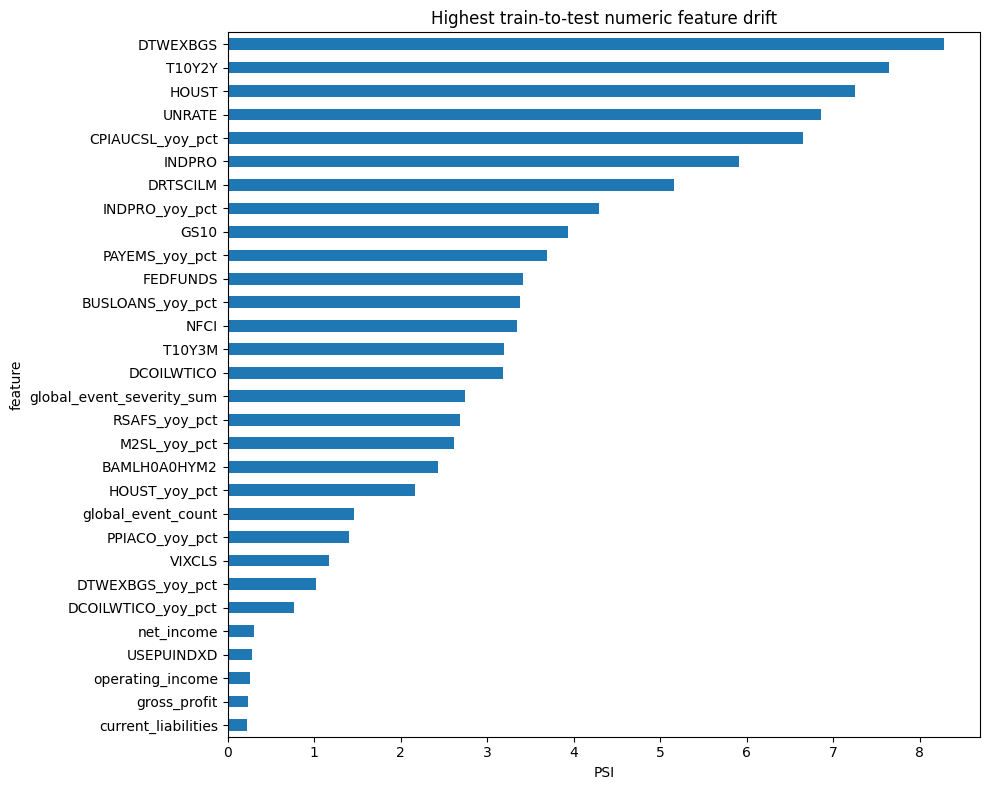

In [48]:
def psi_numeric(expected, actual, bins=10):
    expected = pd.to_numeric(expected, errors='coerce').dropna()
    actual = pd.to_numeric(actual, errors='coerce').dropna()
    if len(expected) < 100 or len(actual) < 100:
        return np.nan
    quantiles = np.unique(np.nanquantile(expected, np.linspace(0, 1, bins + 1)))
    if len(quantiles) < 3:
        return np.nan
    expected_counts = pd.cut(expected, bins=quantiles, include_lowest=True, duplicates='drop').value_counts(normalize=True).sort_index()
    actual_counts = pd.cut(actual, bins=quantiles, include_lowest=True, duplicates='drop').value_counts(normalize=True).sort_index()
    expected_pct = expected_counts.reindex(expected_counts.index.union(actual_counts.index), fill_value=0.0001)
    actual_pct = actual_counts.reindex(expected_pct.index, fill_value=0.0001)
    expected_pct = expected_pct.replace(0, 0.0001)
    actual_pct = actual_pct.replace(0, 0.0001)
    return float(((actual_pct - expected_pct) * np.log(actual_pct / expected_pct)).sum())

if 'manual_temporal_split' in df.columns:
    train = df[df['manual_temporal_split'] == 'train']
    test = df[df['manual_temporal_split'] == 'test']
    drift_rows = []
    for col in feature_candidates:
        if col in train.columns:
            drift_rows.append({
                'feature': col,
                'psi_train_to_test': psi_numeric(train[col], test[col]),
                'train_missing_share': float(train[col].isna().mean()),
                'test_missing_share': float(test[col].isna().mean()),
                'missing_share_change': float(test[col].isna().mean() - train[col].isna().mean()),
            })
    drift = pd.DataFrame(drift_rows).sort_values('psi_train_to_test', ascending=False)
    display(drift.head(60))
    
    plt.figure(figsize=(10, 8))
    drift.head(30).sort_values('psi_train_to_test').plot(x='feature', y='psi_train_to_test', kind='barh', legend=False, ax=plt.gca())
    plt.title('Highest train-to-test numeric feature drift')
    plt.xlabel('PSI')
    plt.tight_layout()
    plt.show()

## 18. Distress Event Manual Review Queue

In [49]:
if 'formal_distress_firm' in df.columns:
    distress_cols = [col for col in ['ticker', 'cik', 'name', 'Sector', 'Industry', 'period_date', 'prediction_date', 'event_date', 'days_to_event', 'distress_next_4q', 'post_event_flag', 'cohort', 'notes'] if col in df.columns]
    distress_firms = df[df['formal_distress_firm'].fillna(0).astype(int) == 1][distress_cols].sort_values(['ticker', 'prediction_date'])
    print('Rows for formal distress firms:', len(distress_firms))
    display(distress_firms.head(100))
    
    if 'distress_next_4q' in df.columns:
        positive_distress = df[df['distress_next_4q'].fillna(0).astype(int) == 1][distress_cols].sort_values(['event_date', 'ticker', 'prediction_date'])
        print('Positive distress_next_4q rows:', len(positive_distress))
        display(positive_distress.head(120))

Rows for formal distress firms: 1385


,ticker,cik,name,Sector,Industry,period_date,prediction_date,event_date,days_to_event,distress_next_4q,post_event_flag,cohort,notes
66,AAMRQ,6201,AMR CORP,Industrials,None,2010-06-30,2010-07-21,2011-11-29,496.0000,0,0,distress_candidates,bankruptcy; event_year=2011; filings=15.0
67,AAMRQ,6201,AMR CORP,Industrials,None,2010-09-30,2010-10-20,2011-11-29,405.0000,1,0,distress_candidates,bankruptcy; event_year=2011; filings=15.0
68,AAMRQ,6201,AMR CORP,Industrials,None,2010-12-31,2011-02-16,2011-11-29,286.0000,1,0,distress_candidates,bankruptcy; event_year=2011; filings=15.0
69,AAMRQ,6201,AMR CORP,Industrials,None,2011-03-31,2011-04-20,2011-11-29,223.0000,1,0,distress_candidates,bankruptcy; event_year=2011; filings=15.0
70,AAMRQ,6201,AMR CORP,Industrials,None,2011-06-30,2011-07-20,2011-11-29,132.0000,1,0,distress_candidates,bankruptcy; event_year=2011; filings=15.0
71,AAMRQ,6201,AMR CORP,Industrials,None,2011-09-30,2011-10-19,2011-11-29,41.0000,1,0,distress_candidates,bankruptcy; event_year=2011; filings=15.0
72,AAMRQ,6201,AMR CORP,Industrials,None,2011-12-31,2012-02-15,2011-11-29,-78.0000,0,1,distress_candidates,bankruptcy; event_year=2011; filings=15.0
73,AAMRQ,6201,AMR CORP,Industrials,None,2012-03-31,2012-04-19,2011-11-29,-142.0000,0,1,distress_candidates,bankruptcy; event_year=2011; filings=15.0
74,AAMRQ,6201,AMR CORP,Industrials,None,2012-06-30,2012-07-18,2011-11-29,-232.0000,0,1,distress_candidates,bankruptcy; event_year=2011; filings=15.0
75,AAMRQ,6201,AMR CORP,Industrials,None,2012-09-30,2012-10-17,2011-11-29,-323.0000,0,1,distress_candidates,bankruptcy; event_year=2011; filings=15.0


Positive distress_next_4q rows: 170


,ticker,cik,name,Sector,Industry,period_date,prediction_date,event_date,days_to_event,distress_next_4q,post_event_flag,cohort,notes
67,AAMRQ,6201,AMR CORP,Industrials,None,2010-09-30,2010-10-20,2011-11-29,405.0000,1,0,distress_candidates,bankruptcy; event_year=2011; filings=15.0
68,AAMRQ,6201,AMR CORP,Industrials,None,2010-12-31,2011-02-16,2011-11-29,286.0000,1,0,distress_candidates,bankruptcy; event_year=2011; filings=15.0
69,AAMRQ,6201,AMR CORP,Industrials,None,2011-03-31,2011-04-20,2011-11-29,223.0000,1,0,distress_candidates,bankruptcy; event_year=2011; filings=15.0
70,AAMRQ,6201,AMR CORP,Industrials,None,2011-06-30,2011-07-20,2011-11-29,132.0000,1,0,distress_candidates,bankruptcy; event_year=2011; filings=15.0
71,AAMRQ,6201,AMR CORP,Industrials,None,2011-09-30,2011-10-19,2011-11-29,41.0000,1,0,distress_candidates,bankruptcy; event_year=2011; filings=15.0
7053,EKDKQ,31235,EASTMAN KODAK CO,Industrials,None,2010-09-30,2010-10-28,2012-01-19,448.0000,1,0,distress_candidates,bankruptcy; event_year=2012; filings=65.0
7054,EKDKQ,31235,EASTMAN KODAK CO,Industrials,None,2010-12-31,2011-02-25,2012-01-19,328.0000,1,0,distress_candidates,bankruptcy; event_year=2012; filings=65.0
7055,EKDKQ,31235,EASTMAN KODAK CO,Industrials,None,2011-03-31,2011-04-28,2012-01-19,266.0000,1,0,distress_candidates,bankruptcy; event_year=2012; filings=65.0
7056,EKDKQ,31235,EASTMAN KODAK CO,Industrials,None,2011-06-30,2011-07-26,2012-01-19,177.0000,1,0,distress_candidates,bankruptcy; event_year=2012; filings=65.0
7057,EKDKQ,31235,EASTMAN KODAK CO,Industrials,None,2011-09-30,2011-11-03,2012-01-19,77.0000,1,0,distress_candidates,bankruptcy; event_year=2012; filings=65.0


## 19. Firm Trajectory Plotter

Change `TICKER_TO_PLOT` and rerun. Use this for manual case studies and dashboard screenshots.

Firm rows: 68


,ticker,cik,name,Sector,Industry,period_date,prediction_date,form,distress_next_4q,success_resilience_next_4q
178,AAPL,320193,APPLE INC,Technology,Consumer Electronics,2021-03-31,2021-04-29,10-Q,0,0
179,AAPL,320193,APPLE INC,Technology,Consumer Electronics,2021-06-30,2021-07-28,10-Q,0,0
180,AAPL,320193,APPLE INC,Technology,Consumer Electronics,2021-09-30,2021-10-29,10-K,0,0
181,AAPL,320193,APPLE INC,Technology,Consumer Electronics,2021-12-31,2022-01-28,10-Q,0,0
182,AAPL,320193,APPLE INC,Technology,Consumer Electronics,2022-03-31,2022-04-29,10-Q,0,0
183,AAPL,320193,APPLE INC,Technology,Consumer Electronics,2022-06-30,2022-07-29,10-Q,0,0
184,AAPL,320193,APPLE INC,Technology,Consumer Electronics,2022-09-30,2022-10-28,10-K,0,1
185,AAPL,320193,APPLE INC,Technology,Consumer Electronics,2022-12-31,2023-02-03,10-Q,0,1
186,AAPL,320193,APPLE INC,Technology,Consumer Electronics,2023-03-31,2023-05-05,10-Q,0,1
187,AAPL,320193,APPLE INC,Technology,Consumer Electronics,2023-06-30,2023-08-04,10-Q,0,1


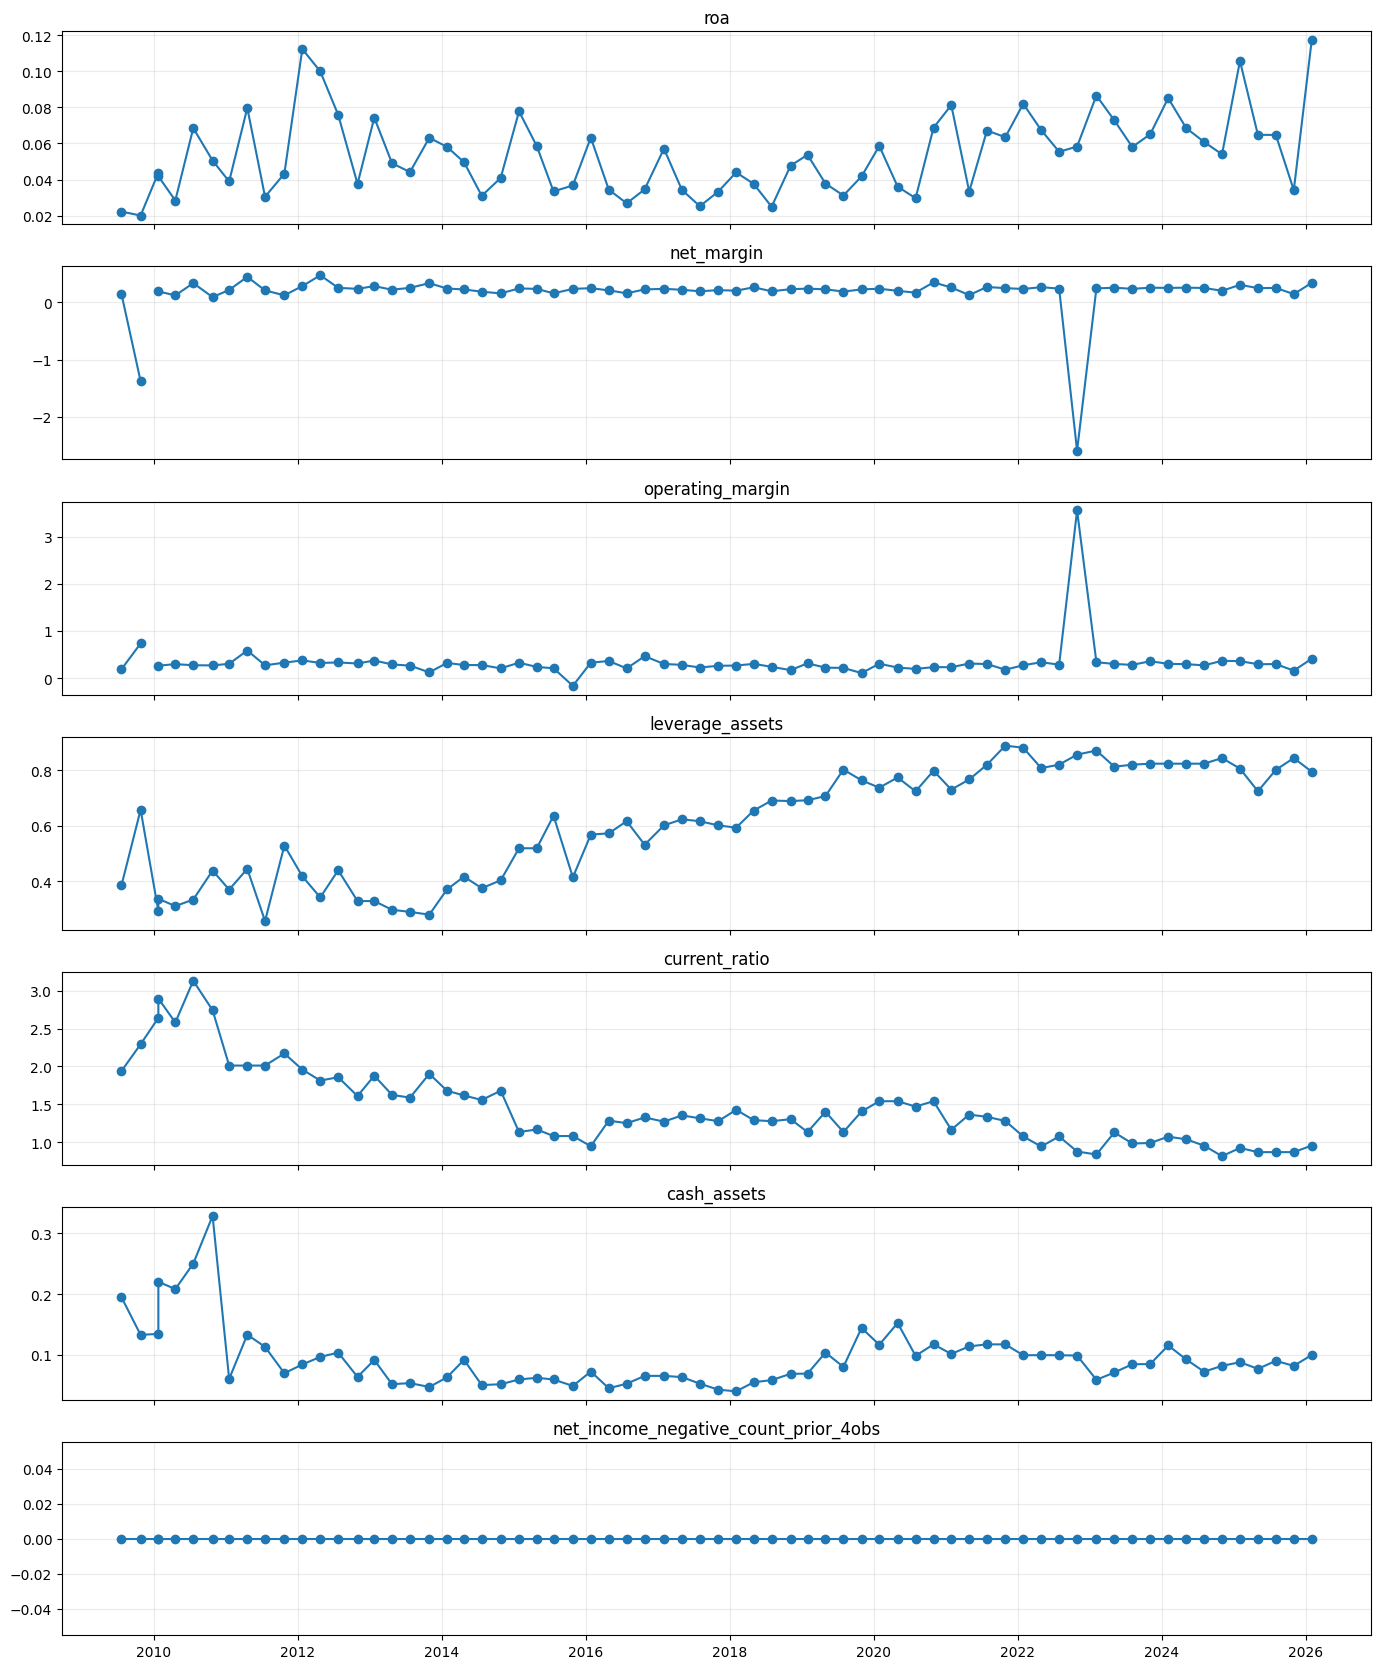

In [50]:
TICKER_TO_PLOT = 'AAPL'
PLOT_COLS = [col for col in ['roa', 'net_margin', 'operating_margin', 'leverage_assets', 'current_ratio', 'cash_assets', 'net_income_negative_count_prior_4obs'] if col in df.columns]

def plot_firm_trajectory(ticker, cols):
    if 'ticker' not in df.columns or 'prediction_date' not in df.columns:
        print('Missing ticker or prediction_date column')
        return
    g = df[df['ticker'].astype(str).str.upper() == str(ticker).upper()].sort_values('prediction_date')
    if g.empty:
        print('Ticker not found:', ticker)
        return
    print('Firm rows:', len(g))
    display(g[[col for col in ['ticker', 'cik', 'name', 'Sector', 'Industry', 'period_date', 'prediction_date', 'form', 'distress_next_4q', 'success_resilience_next_4q'] if col in g.columns]].tail(20))
    n = len(cols)
    fig, axes = plt.subplots(n, 1, figsize=(14, max(3, 2.4 * n)), sharex=True)
    if n == 1:
        axes = [axes]
    for ax, col in zip(axes, cols):
        ax.plot(g['prediction_date'], pd.to_numeric(g[col], errors='coerce'), marker='o', linewidth=1.5)
        ax.set_title(col)
        ax.grid(True, alpha=0.25)
        if 'event_date' in g.columns and g['event_date'].notna().any():
            for event_date in g['event_date'].dropna().unique():
                ax.axvline(event_date, color='red', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

plot_firm_trajectory(TICKER_TO_PLOT, PLOT_COLS)

## 20. Macro, Regime, and Event Context Inside the Panel

Context columns in panel: 67


,context_column
0,high_rate_regime
1,market_stress_regime
2,credit_spread_stress_regime
3,yield_curve_inversion_regime
4,inflation_pressure_regime
5,oil_shock_regime
6,strong_dollar_regime
7,demand_slowdown_regime
8,credit_tightening_regime
9,crisis_regime


,global_event_count,global_event_severity_sum,high_rate_regime,market_stress_regime,credit_spread_stress_regime,yield_curve_inversion_regime,inflation_pressure_regime,oil_shock_regime,strong_dollar_regime,demand_slowdown_regime,credit_tightening_regime,crisis_regime
year,,,,,,,,,,,,
2009,1.0000,5.0000,0.0000,0.3664,1.0000,0.0000,0.0000,0.4377,0.2595,0.6463,1.0000,1.0000
2010,1.0000,4.0000,0.0000,0.1655,1.0000,0.0000,0.0000,0.3107,0.0000,0.0000,0.0000,0.0000
2011,1.7837,7.1350,0.0000,0.4154,0.5642,0.0000,0.0000,0.2236,0.0000,0.0000,0.0000,0.0000
2012,1.0000,4.0000,0.0000,0.0031,0.9900,0.0000,0.0000,0.0000,0.2744,0.0000,0.2467,0.0000
2013,0.0000,0.0000,0.0000,0.0000,0.0861,0.0000,0.0000,0.0000,0.0015,0.0000,0.0000,0.0000
2014,0.5199,2.0794,0.0000,0.0052,0.0165,0.0000,0.0000,0.0000,0.1476,0.0000,0.0000,0.0000
2015,1.5206,5.5619,0.0000,0.0133,0.5295,0.0000,0.0000,0.0000,0.9469,0.0000,0.2544,0.0000
2016,0.9451,3.0601,0.0000,0.0356,0.8419,0.0000,0.0000,0.0186,0.2910,0.0000,1.0000,0.0000
2017,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.2310,0.0093,0.0000,0.2468,0.0000


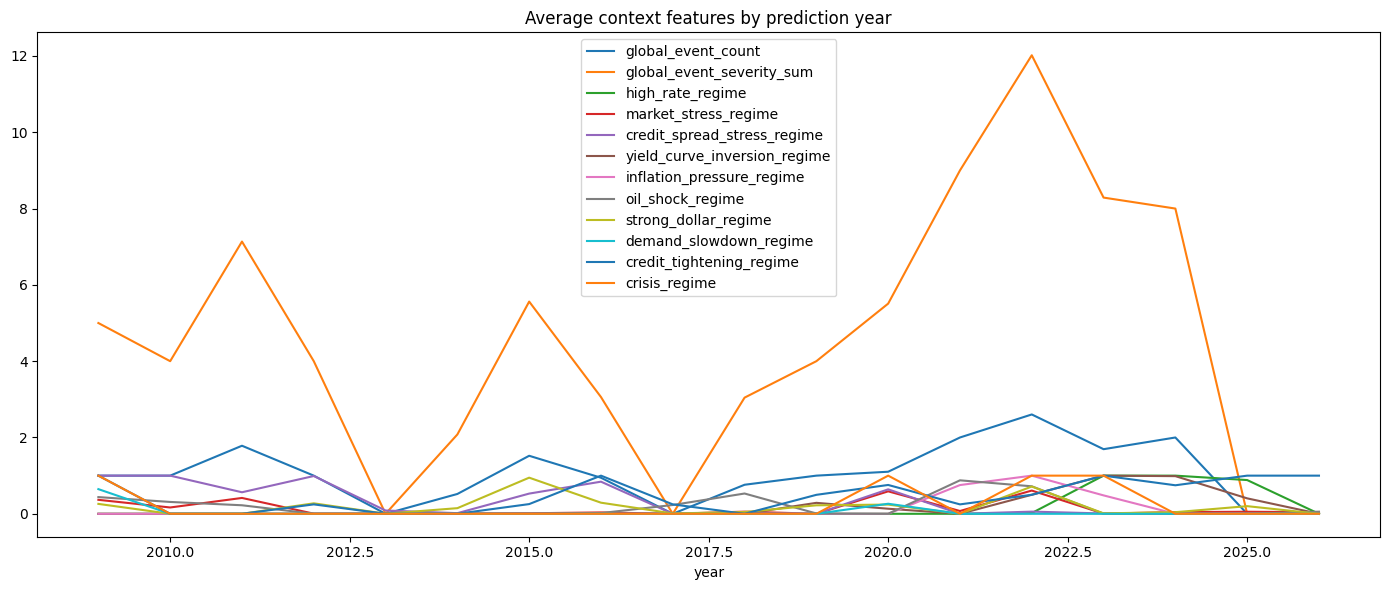

,global_event_count,global_event_severity_sum
Sector,,
Agriculture,1.3929,6.2857
Real Estate,1.1399,4.8694
Technology,1.1354,4.8506
Consumer Cyclical,1.1324,4.8111
Basic Materials,1.1223,4.7962
Consumer Defensive,1.1190,4.7490
Industrials,1.1144,4.7389
Healthcare,1.1116,4.7322
Communication Services,1.1040,4.6936


In [51]:
context_cols = [col for col in REGIME_COLS + EVENT_COLS + MACRO_COLS if col in df.columns]
print('Context columns in panel:', len(context_cols))
display(pd.Series(context_cols).to_frame('context_column').head(120))

if {'prediction_date', 'Sector'}.issubset(df.columns) and context_cols:
    event_summary_cols = [col for col in ['global_event_count', 'global_event_severity_sum'] if col in df.columns]
    regime_summary_cols = [col for col in REGIME_COLS if col in df.columns]
    selected = event_summary_cols + regime_summary_cols[:10]
    if selected:
        context_by_year = df.assign(year=df['prediction_date'].dt.year).groupby('year')[selected].mean()
        display(context_by_year.tail(20))
        context_by_year.plot(figsize=(14, 6), title='Average context features by prediction year')
        plt.tight_layout()
        plt.show()
    
    if event_summary_cols:
        context_by_sector = df.groupby('Sector')[event_summary_cols].mean().sort_values(event_summary_cols[0], ascending=False)
        display(context_by_sector)

## 21. Manual Review Queue

This combines common issues into a set of rows worth manually opening. It does not mean every row is wrong.

In [52]:
review_masks = []

if {'period_date', 'prediction_date'}.issubset(df.columns):
    review_masks.append(('period_after_prediction', df['period_date'] > df['prediction_date']))

if 'total_assets' in df.columns:
    review_masks.append(('missing_total_assets', df['total_assets'].isna()))
    review_masks.append(('negative_total_assets', pd.to_numeric(df['total_assets'], errors='coerce') < 0))

if 'total_liabilities' in df.columns:
    review_masks.append(('missing_total_liabilities', df['total_liabilities'].isna()))

if 'roa' in df.columns:
    review_masks.append(('extreme_roa_abs_gt_5', pd.to_numeric(df['roa'], errors='coerce').abs() > 5))

if 'leverage_assets' in df.columns:
    lev = pd.to_numeric(df['leverage_assets'], errors='coerce')
    review_masks.append(('leverage_assets_negative_or_gt_3', (lev < 0) | (lev > 3)))

review = df[[col for col in ['ticker', 'cik', 'name', 'Sector', 'period_date', 'prediction_date', 'form', 'sec_zip', 'distress_next_4q', 'success_resilience_next_4q'] if col in df.columns]].copy()
review_reasons = pd.Series('', index=df.index, dtype='object')
for reason, mask in review_masks:
    mask = mask.fillna(False)
    review_reasons.loc[mask] = review_reasons.loc[mask] + reason + '; '

review['review_reasons'] = review_reasons
review_queue = review[review['review_reasons'].str.len() > 0].copy()
print('Manual review queue rows:', len(review_queue))
display(review_queue.head(150))

if EXPORT_RESULTS:
    EXPORT_DIR.mkdir(parents=True, exist_ok=True)
    review_queue.to_csv(EXPORT_DIR / 'firm_panel_manual_review_queue.csv', index=False)

Manual review queue rows: 7367


,ticker,cik,name,Sector,period_date,prediction_date,form,sec_zip,distress_next_4q,success_resilience_next_4q,review_reasons
66,AAMRQ,6201,AMR CORP,Industrials,2010-06-30,2010-07-21,10-Q,2010q3,0,<NA>,missing_total_liabilities;
67,AAMRQ,6201,AMR CORP,Industrials,2010-09-30,2010-10-20,10-Q,2010q4,1,<NA>,missing_total_liabilities;
68,AAMRQ,6201,AMR CORP,Industrials,2010-12-31,2011-02-16,10-K,2011q1,1,<NA>,missing_total_liabilities;
69,AAMRQ,6201,AMR CORP,Industrials,2011-03-31,2011-04-20,10-Q,2011q2,1,<NA>,missing_total_liabilities;
70,AAMRQ,6201,AMR CORP,Industrials,2011-06-30,2011-07-20,10-Q,2011q3,1,<NA>,missing_total_liabilities;
...,...,...,...,...,...,...,...,...,...,...,...
299,ABT,1800,ABBOTT LABORATORIES,Healthcare,2016-09-30,2016-11-03,10-Q,2016q4,0,<NA>,missing_total_liabilities;
300,ABT,1800,ABBOTT LABORATORIES,Healthcare,2016-12-31,2017-02-17,10-K,2017q1,0,<NA>,missing_total_liabilities;
301,ABT,1800,ABBOTT LABORATORIES,Healthcare,2017-03-31,2017-05-03,10-Q,2017q2,0,<NA>,missing_total_liabilities;
302,ABT,1800,ABBOTT LABORATORIES,Healthcare,2017-06-30,2017-08-02,10-Q,2017q3,0,<NA>,missing_total_liabilities;


## 22. Optional Exports

In [53]:
if EXPORT_RESULTS:
    EXPORT_DIR.mkdir(parents=True, exist_ok=True)
    target_summary.to_csv(EXPORT_DIR / 'target_summary.csv', index=False)
    duplicate_report.to_csv(EXPORT_DIR / 'duplicate_key_report.csv', index=False)
    missing.to_frame('missing_share').to_csv(EXPORT_DIR / 'missingness_by_column.csv')
    print('Wrote manual audit exports to:', EXPORT_DIR)
else:
    print('EXPORT_RESULTS is False. Set it to True in the setup cell if you want CSV outputs.')

EXPORT_RESULTS is False. Set it to True in the setup cell if you want CSV outputs.
